# GA (Roulette + IPOX + Swap) – Toggle Missed-Order Penalty + ROP
Versi dengan **toggle** `USE_MISSED_ORDER_PENALTY` dan breakdown biaya yang transparan.

In [1]:

# -*- coding: utf-8 -*-
import math, random, time
from typing import Dict, Tuple, List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re, time
from datetime import datetime

RANDOM_SEED = 123
POP_SIZE = 120
GENERATIONS = 300

# Toggle penalti
USE_PENALTIES = True               # penalti kapasitas, Q<=D, SS target, budget
USE_MISSED_ORDER_PENALTY = True     # penalti BIG_COST saat D>0 & Q=0

# GA params
IPOX_N_MIN_FRAC = 0.05
IPOX_N_MAX_FRAC = 0.25
PC_BASE    = 0.75
C_INTERVAL = 0.20
PO_BASE    = 0.10
O_INTERVAL = 0.15
SWAP_COUNT = 1

# VNS params (dipakai di Hybrid/VNS-only)
K_MAX = 2
LS_MAX_ITERS = 5
SHAKE_INTENSITY = [1,2,3,4,5]
DELTA_SCALE = [0.05,0.10,0.15,0.20,0.25]
N_STARTS = 10

# Penalti (aktif bila USE_PENALTIES=True)
PENALTY_SS_TARGET = 1e9
PENALTY_CAPACITY  = 1e9
PENALTY_BUDGET    = 1e9
PENALTY_Q_LEQ_D   = 1e9

# Fill rate
TARGET_FILL = 0.80
PENALTY_FILL = 1e9

# Statistik
Z_SERVICE = 1.28
LEAD_TIME_UNIT   = 'days'   # 'days' atau 'months'
USE_POISSON_SIGMA = True
SIGMA_OVERRIDE: Dict[int, float] = {}

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
plt.style.use('seaborn-v0_8')


## Load Data & Inisialisasi

In [2]:

# ========= Load Data =========
#-- Helper Functions --#
def _to_number(x: str) -> float:
    if pd.isna(x): return np.nan
    if isinstance(x, (int,float)): return float(x)
    x = str(x).replace('"','').replace("'",'').replace(',','').strip()
    if x=='': return np.nan
    return float(x)

# Cost Data
raw = pd.read_csv('Cost_Small.csv', dtype=str)
for c in [c for c in raw.columns if c not in ['Material','Material Description']]:
    raw[c] = raw[c].apply(_to_number)

# Distribution Centers
M = raw.shape[0]
DCs = []
for j in range(1,10):
    if all(f in raw.columns for f in [f'hi{j}',f'Ki{j}',f'Di{j}',f'Ci{j}']):
        DCs.append(j)
N = len(DCs); assert N>0, 'Kolom DC (hi*/Ki*/Di*/Ci*) tidak lengkap'

# Customers
customers = [k for k in range(1,101) if f'di{k}' in raw.columns]
O = len(customers)
assert 'Ii' in raw.columns, 'Kolom Ii tidak ditemukan di Cost.csv'

# Matriks parameter per-DC (h_ij, K_ij, D_ij, C_ij)
h    = np.zeros((M,N))
K    = np.zeros((M,N))
D_dc = np.zeros((M,N))
C    = np.zeros((M,N))
for i in range(M):
    for jj,j in enumerate(DCs):
        h[i,jj]    = 0.0 if pd.isna(raw.loc[i, f'hi{j}']) else raw.loc[i, f'hi{j}']
        K[i,jj]    = 0.0 if pd.isna(raw.loc[i, f'Ki{j}']) else raw.loc[i, f'Ki{j}']
        D_dc[i,jj] = 0.0 if pd.isna(raw.loc[i, f'Di{j}']) else raw.loc[i, f'Di{j}']
        C[i,jj]    = 0.0 if pd.isna(raw.loc[i, f'Ci{j}']) else raw.loc[i, f'Ci{j}']

# Demand per customer (d_ik)
D_cust = np.zeros((M,O))
for i in range(M):
    for kk,k in enumerate(customers):
        col = f'di{k}'
        D_cust[i,kk] = 0.0 if col not in raw.columns or pd.isna(raw.loc[i, col]) else raw.loc[i, col]

D_tot_cust = D_cust.sum(axis=1)
D_tot_dc   = D_dc.sum(axis=1)
D_tot      = np.where(D_tot_cust>0, D_tot_cust, D_tot_dc)

# p_ik (penalty per-customer) atau fallback
pik_cols = [f'pik{k}' for k in customers if f'pik{k}' in raw.columns]
if len(pik_cols) == O:
    p_ik = np.zeros((M,O))
    for i in range(M):
        for kk,k in enumerate(customers):
            p_ik[i,kk] = 0.0 if pd.isna(raw.loc[i, f'pik{k}']) else raw.loc[i, f'pik{k}']
else:
    pi_cols = [f'pi{j}' for j in DCs if f'pi{j}' in raw.columns]
    p_i = np.zeros(M)
    for i in range(M):
        if pi_cols:
            vals=[raw.loc[i,c] for c in pi_cols]
            p=np.nanmean(vals)
            if np.isnan(p): p=0.003*np.nanmean(K[i])
        else:
            p=0.003*np.nanmean(K[i])
        p_i[i]=0.0 if np.isnan(p) else p
    p_ik = np.repeat(p_i.reshape(-1,1), O, axis=1)

# Budget per part
I_i = raw['Ii'].fillna(0.0).astype(float).values

#SOH per part (initial inventory)
assert 'SOH' in raw.columns, 'Kolom SOH tidak ditemukan di Cost.csv'
SOH_i = raw['SOH'].fillna(0.0).astype(float).values

# Lead time & sigma
lt_df = pd.read_csv('Act LT_Small.csv')
L_samples = []
for i in range(M):
    col = f'Part_{i+1}'
    vals = pd.to_numeric(lt_df[col], errors='coerce').dropna().values
    L_samples.append(np.mean(vals) if vals.size>0 else 0.0)
L_samples = np.array(L_samples)
L_i = L_samples/30.0 if LEAD_TIME_UNIT=='days' else L_samples.copy()

mu_i = D_tot.astype(float)
if USE_POISSON_SIGMA:
    sigma_i = np.sqrt(np.maximum(mu_i, 0.0))
else:
    sigma_i = np.array([SIGMA_OVERRIDE.get(i+1, np.sqrt(max(mu_i[i], 0.0))) for i in range(M)], dtype=float)

# ========= Safety Stock Calculation =========
SS_target = Z_SERVICE * np.sqrt(np.maximum(L_i, 0.0)) * np.maximum(sigma_i, 0.0)

# EOQ init Calculation
K_bar = np.where(np.isnan(K).all(axis=1), 0.0, np.nanmin(K, axis=1))
h_bar = np.where(np.isnan(h).all(axis=1), 0.0, np.nanmin(h, axis=1))
D_for_eoq = np.where(D_tot_dc > 0, D_tot_dc, D_tot)
EOQ_i = np.sqrt(np.maximum(2.0 * np.maximum(D_for_eoq, 0.0) * np.maximum(K_bar, 1e-9) / np.maximum(h_bar, 1e-9), 0.0))

 # Inisialisasi Q0 & SS0 ========= Initial Solution =========
D_prop = D_dc / np.maximum(D_dc.sum(axis=1, keepdims=True), 1e-9)
SS_prop = np.ones_like(D_prop) / N
Q0  = np.floor((EOQ_i.reshape(-1,1) * D_prop)).astype(int)
SS0 = np.ceil((SS_target.reshape(-1,1) * SS_prop)).astype(int)

# ========= GA Encoding/Decoding =========
# Batas variabel
# Optional: map each customer to a DC index (0..N-1). If None, customers are assigned round-robin.
# Provide a list of length O to override, e.g. CUSTOMER_TO_DC = [0,0,1,1,2,...]
CUSTOMER_TO_DC = None
if CUSTOMER_TO_DC is None:
    cust_to_dc_idx = np.arange(O) % N
else:
    cust_to_dc_idx = np.array(CUSTOMER_TO_DC, dtype=int)
    assert cust_to_dc_idx.shape[0] == O, 'CUSTOMER_TO_DC must have length O'
# Compute demand (per material) assigned to each DC from customers' demands
D_cust_assigned = np.zeros((M, N))
for j in range(N):
    mask = (cust_to_dc_idx == j)
    if mask.any():
        D_cust_assigned[:, j] = D_cust[:, mask].sum(axis=1)
# Upper bounds: ensure Q_ij ≤ D_dc, ≤ capacity C, and ≤ demand of customers assigned to that DC
Q_lb = np.zeros((M,N), dtype=int)
Q_ub = np.floor(np.minimum(np.minimum(D_dc, C), D_cust_assigned)).astype(int)
# Enforce per-DC safety stock target as a lower bound for SS (SS_ij ≥ SS_target_i)
SS_lb = np.ceil(np.repeat(SS_target.reshape(-1,1), N, axis=1)).astype(int)
SS_ub = np.floor(C).astype(int)

def _coverage_ss_floor(target):
    SSf = np.zeros((M, N), dtype=int)
    for i in range(M):
        D_i = float(np.sum(D_cust[i]))
        cover_need = (target * D_i - float(SOH_i[i])) if D_i > 0 else 0.0
        need_units = max(cover_need, float(np.ceil(SS_target[i])))
        cap_room = np.maximum(0, SS_ub[i] - Q_ub[i])
        bud_left = float(I_i[i]) - float(np.sum(Q_ub[i] * K[i]))
        rem = max(0.0, need_units)
        for j in np.argsort(K[i]):
            if rem <= 0:
                break
            kij = max(float(K[i, j]), 1e-9)
            take = min(rem, float(cap_room[j]), (bud_left / kij if bud_left > 0 else 0.0))
            take = int(max(0, np.floor(take)))
            SSf[i, j] = take
            rem -= take
            bud_left -= take * kij
    return SSf

SS_cover_lb = _coverage_ss_floor(TARGET_FILL)
SS_lb = np.minimum(SS_cover_lb, SS_ub).astype(int)
SS0   = np.clip(SS0, SS_lb, SS_ub)

VAR_COUNT = 2*M*N

#========= Packing / Unpacking =========
def pack(Q: np.ndarray, SS: np.ndarray) -> np.ndarray:
    return np.concatenate([Q.reshape(-1), SS.reshape(-1)])

def unpack(chrom: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    Q_flat  = chrom[: M*N]
    SS_flat = chrom[M*N : 2*M*N]
    return Q_flat.reshape(M, N), SS_flat.reshape(M, N)

print(f'Jumlah part (M): {M}, jumlah DC (N): {N}, jumlah customer (O): {O}')

print("Fill-rate targeting enabled:")
print(f"  TARGET_FILL = {TARGET_FILL}, PENALTY_FILL = {PENALTY_FILL:.0e}")
print("  SS coverage floor per part (sum over DCs):", SS_lb.sum(axis=1))
print("  SS_lb total = %d, SS_ub total = %d" % (int(SS_lb.sum()), int(SS_ub.sum())))

Jumlah part (M): 1, jumlah DC (N): 1, jumlah customer (O): 1
Fill-rate targeting enabled:
  TARGET_FILL = 0.8, PENALTY_FILL = 1e+09
  SS coverage floor per part (sum over DCs): [32]
  SS_lb total = 32, SS_ub total = 20000


## Objective & Utilities (dengan toggle penalti missed-order)

In [3]:

# ========= Utilities =========
#Supply Constraint: Q_ij + SS_ij <= C_ij)
def clamp_to_bounds(Q: np.ndarray, SS: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    Q  = np.minimum(np.maximum(Q,  Q_lb), Q_ub)
    SS = np.minimum(np.maximum(SS, SS_lb), SS_ub)
    # enforce Q+SS ≤ C: kurangi SS dahulu, lalu Q
    excess = np.maximum(Q + SS - C, 0)
    reduce_ss = np.minimum(SS, excess)
    SS = SS - reduce_ss
    excess = np.maximum(Q + SS - C, 0)
    reduce_q = np.minimum(Q, excess)
    Q = Q - reduce_q
    return Q, SS

#Objective function
def compute_cost(Q: np.ndarray, SS: np.ndarray):
    # Holding
    holding = float(np.sum(h * (Q/2.0 + SS)))

    # Ordering murni + penalti missed-order dipisah
    ordering = 0.0
    order_miss_penalty = 0.0
    BIG_COST = 1e12
    for i in range(M):
        for j in range(N):
            Dij = D_dc[i, j]
            Qij = max(Q[i, j], 0)
            if Dij <= 0:
                continue
            if Qij <= 0:
                if USE_MISSED_ORDER_PENALTY and Q_ub[i, j] > 0:
                    order_miss_penalty += BIG_COST
            else:
                ordering += K[i, j] * (Dij / Qij)

    # Shortage per-customer
    shortage_cost = 0.0
    shortage_volume = 0.0
    total_demand = 0.0
    for i in range(M):
        S_i     = float(np.sum(Q[i] + SS[i]) + SOH_i[i])
        D_i_tot = float(np.sum(D_cust[i]))
        if D_i_tot <= 0.0:
            continue
        B_i_tot = max(0.0, D_i_tot - S_i)
        shortage_volume += B_i_tot
        total_demand += D_i_tot
        if B_i_tot <= 1e-12:
            continue
        alloc = (D_cust[i] / D_i_tot) * B_i_tot
        shortage_cost += float(np.sum(p_ik[i] * alloc))

    # Supply/Budget Constraint: ∑(Q_ij + SS_ij) * K_i ≤ I_i for each material i
    pen_budget = 0.0
    BIG_BUDGET_PENALTY = 1e12
    for i in range(M):
        total_inv_cost_i = float(np.sum((Q[i] + SS[i]) * K[i]))
        if total_inv_cost_i > I_i[i]:
            excess_budget = total_inv_cost_i - I_i[i]
            pen_budget += BIG_BUDGET_PENALTY * (excess_budget / max(I_i[i], 1.0))

    # Penalti opsional lainnya
    pen_cap = pen_qleqd = pen_ss = 0.0
    if USE_PENALTIES:
        cap_violation  = np.maximum(Q + SS - C, 0)
        pen_cap        = (cap_violation * PENALTY_CAPACITY).sum()

        q_leq_d_violation = np.maximum(Q - D_cust_assigned, 0)
        pen_qleqd         = (q_leq_d_violation * PENALTY_Q_LEQ_D).sum()

        ss_deficit = np.maximum(SS_target - SS.sum(axis=1), 0.0)
        pen_ss     = float(np.sum(ss_deficit) * PENALTY_SS_TARGET)

    # Fill rate
    fill_rate = 1 - (shortage_volume / total_demand) if total_demand > 0 else 1.0
    pen_fill = PENALTY_FILL * max(0.0, TARGET_FILL - fill_rate)

    total_basic   = holding + ordering + shortage_cost
    total_penalty = order_miss_penalty + pen_cap + pen_qleqd + pen_ss + pen_budget + pen_fill
    total_all     = total_basic + total_penalty

    breakdown = {
        'holding'           : holding,
        'ordering'          : ordering,
        'shortage'          : shortage_cost,
        'order_miss_penalty': order_miss_penalty,
        'pen_cap'           : pen_cap,
        'pen_q_leq_d'       : pen_qleqd,
        'pen_ss'            : pen_ss,
        'pen_budget'        : pen_budget,
        'pen_fill'          : pen_fill,
        'total_basic'       : total_basic,
        'total_penalty'     : total_penalty,
        'total'             : total_all,
        'fill_rate'         : fill_rate,
    }
    return total_all, breakdown

# ROP helper
def compute_rop(Q: np.ndarray, SS: np.ndarray) -> np.ndarray:
    mu_lt = D_dc * L_i.reshape(-1,1)
    return mu_lt + SS


## GA Operators

In [4]:

def init_individual() -> np.ndarray:
    Q  = Q0.copy()
    SS = SS0.copy()
    for i in range(M):
        for j in range(N):
            qmax = int(Q_ub[i, j])
            smax = int(SS_ub[i, j])
            if qmax > 0:
                step_q = max(1, qmax//10)
                Q[i, j] = max(0, int(Q[i, j] + np.random.randint(-step_q, step_q+1)))
            if smax > 0:
                step_s = max(1, smax//10)
                SS[i, j] = max(0, int(SS[i, j] + np.random.randint(-step_s, step_s+1)))
    Q, SS = clamp_to_bounds(Q, SS)
    return pack(Q, SS)

def roulette_wheel_selection(pop: List[np.ndarray], costs: List[float]) -> np.ndarray:
    arr = np.array(costs, dtype=float)
    min_cost = arr.min()
    scores = 1.0 / (1.0 + (arr - min_cost))
    total_score = scores.sum()
    if total_score <= 0 or not np.isfinite(total_score):
        return pop[np.random.randint(len(pop))].copy()
    probs = scores / total_score
    cum = np.cumsum(probs)
    r = np.random.rand()
    idx = int(np.searchsorted(cum, r, side='right'))
    idx = min(idx, len(pop)-1)
    return pop[idx].copy()

def ipox_crossover(p1: np.ndarray, p2: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    L = len(p1)
    n_min = max(1, int(IPOX_N_MIN_FRAC * L))
    n_max = max(n_min, int(IPOX_N_MAX_FRAC * L))
    n_pick = np.random.randint(n_min, n_max+1)
    idxs = np.random.choice(L, size=n_pick, replace=False)
    mask = np.zeros(L, dtype=bool); mask[idxs] = True
    c1 = np.full(L, 0, dtype=p1.dtype)
    c1[mask]  = p1[mask]
    c1[~mask] = p2[~mask]
    c2 = np.full(L, 0, dtype=p1.dtype)
    c2[mask]  = p2[mask]
    c2[~mask] = p1[~mask]
    return c1, c2

def swap_mutation(chrom: np.ndarray, swaps: int = 1) -> np.ndarray:
    L = len(chrom)
    c = chrom.copy()
    for _ in range(max(1, swaps)):
        i, j = np.random.randint(0, L), np.random.randint(0, L)
        while j == i:
            j = np.random.randint(0, L)
        c[i], c[j] = c[j], c[i]
    return c


## GA Runner

Gen 20: best=20,530,060.69, mean=49,970,205.80, time=0.43 sec
Gen 40: best=20,530,060.69, mean=68,087,218.17, time=0.87 sec
Gen 60: best=20,530,060.69, mean=81,674,977.45, time=1.26 sec
Gen 80: best=20,530,060.69, mean=61,293,338.53, time=1.65 sec
Gen 100: best=20,530,060.69, mean=92,998,110.19, time=2.03 sec
Gen 120: best=20,530,060.69, mean=45,440,952.70, time=2.44 sec
Gen 140: best=20,530,060.69, mean=68,087,218.17, time=2.84 sec
Gen 160: best=20,530,060.69, mean=70,351,844.72, time=3.21 sec
Gen 180: best=20,530,060.69, mean=63,557,965.08, time=3.59 sec
Gen 200: best=20,530,060.69, mean=86,204,230.55, time=4.00 sec
Gen 220: best=20,530,060.69, mean=56,764,085.44, time=4.38 sec
Gen 240: best=20,530,060.69, mean=56,764,085.44, time=4.73 sec
Gen 260: best=20,530,060.69, mean=59,028,711.98, time=5.09 sec
Gen 280: best=20,530,060.69, mean=49,970,205.80, time=5.45 sec
Gen 300: best=20,530,060.69, mean=47,705,579.25, time=5.78 sec

=== HASIL TERBAIK (GA) ===
Total Cost (all) : 20,530,060.6

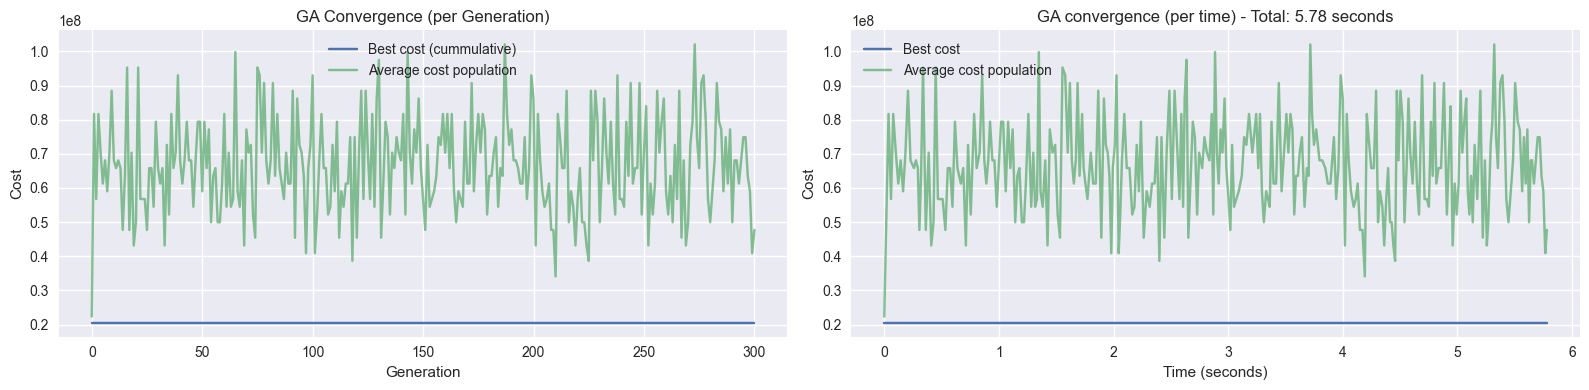

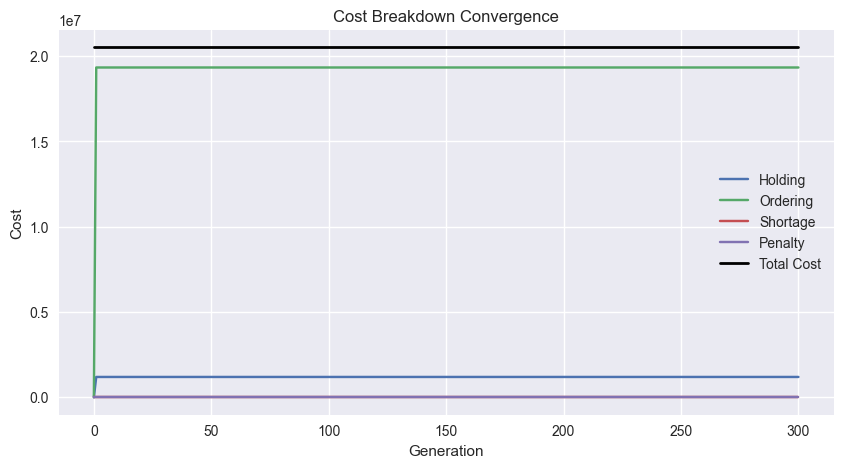

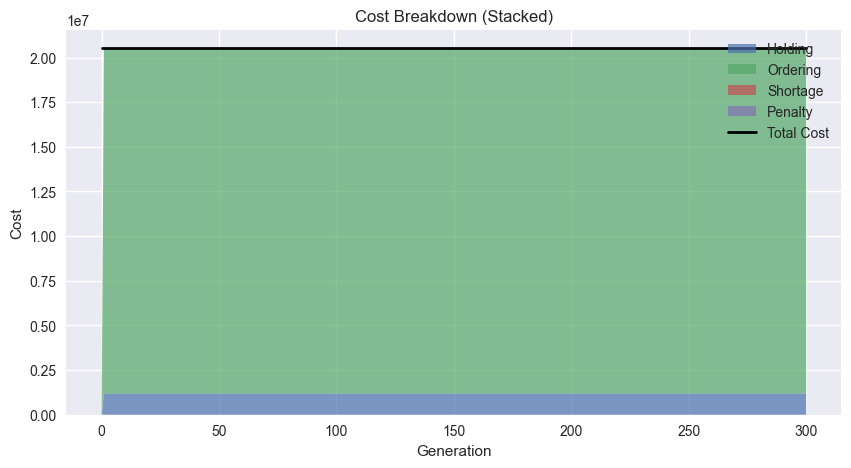

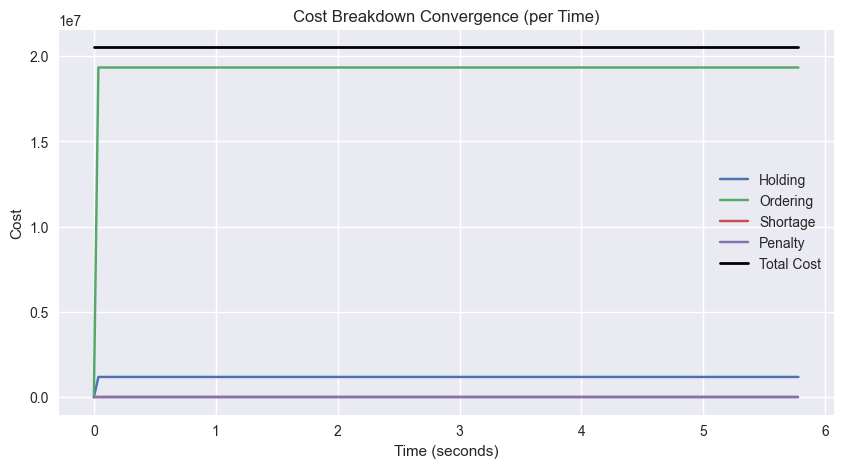

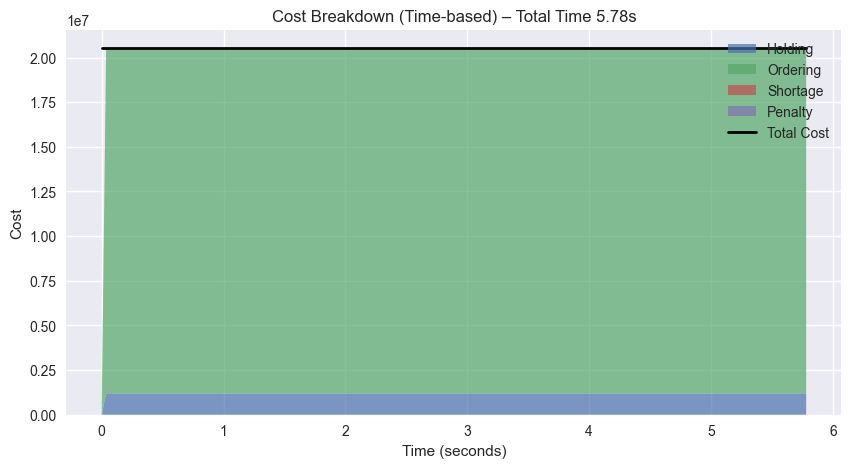

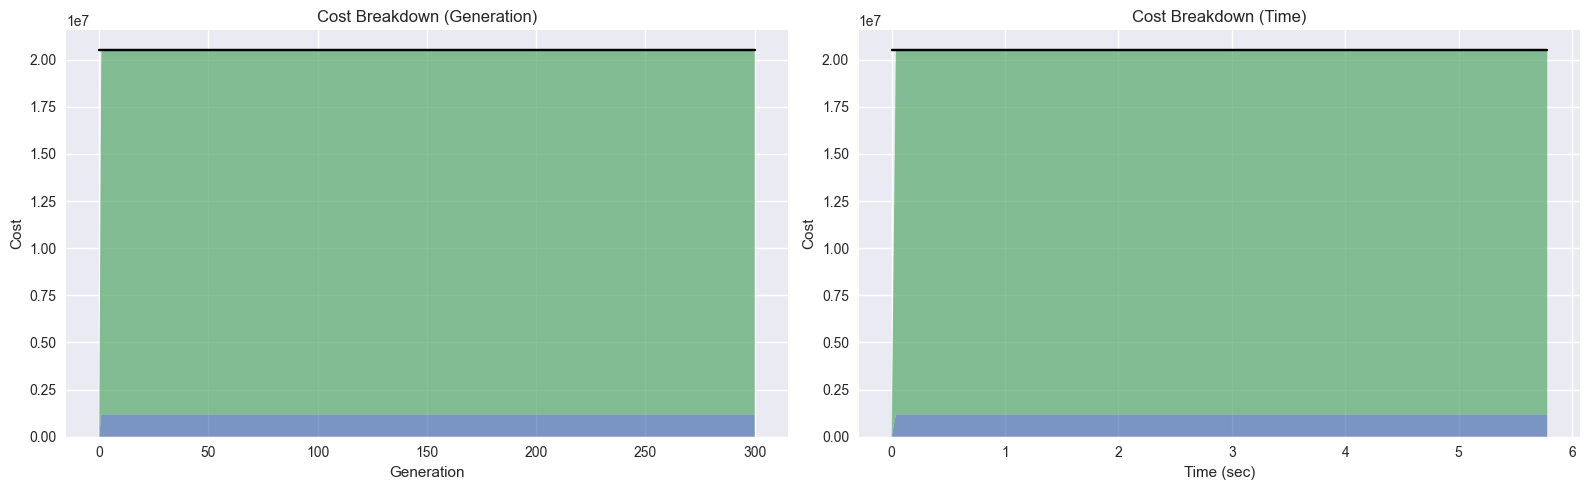

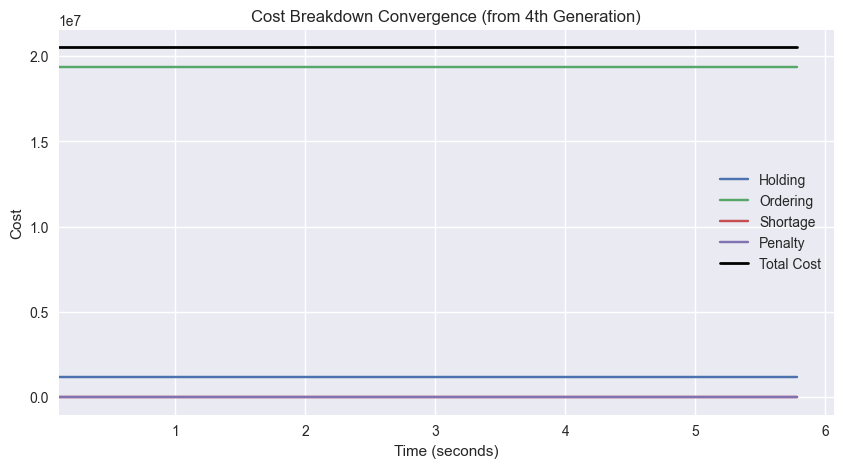

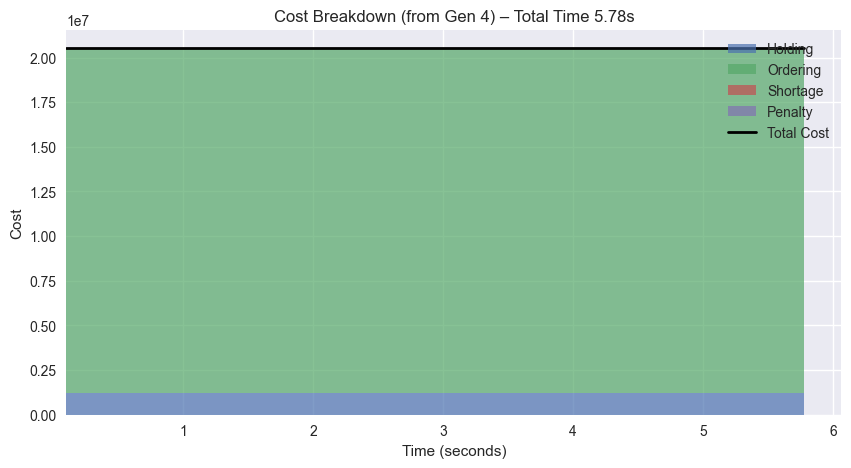

Disimpan: GA_convergence_history_4.csv
Disimpan: GA_best_solution_ipox_4.csv
SS vs target:
Part 0: SS_sum=32, target=31
Total demand: 480.0
Max possible supply: 20480


In [5]:

def run_ga(pop_size=POP_SIZE, generations=GENERATIONS):
    t0 = time.perf_counter()
    population = [init_individual() for _ in range(pop_size)]
    costs = []
    for chrom in population:
        Q, SS = unpack(chrom)
        f, _ = compute_cost(Q, SS)
        costs.append(f)
    best_idx = int(np.argmin(costs))
    best_chrom = population[best_idx].copy()
    best_cost = float(costs[best_idx])

    best_hist, mean_hist = [best_cost], [float(np.mean(costs))]
    time_hist=[0.0]
    holding_hist = [0.0]
    ordering_hist = [0.0]
    shortage_hist = [0.0]
    penalty_hist = [0.0]

    for T in range(1, generations+1):
        new_pop: List[np.ndarray] = []
        new_pop.append(best_chrom.copy())  # elitism
        Pc_T = min(max(PC_BASE + C_INTERVAL * np.random.rand(), 0.0), 1.0)
        Po_T = min(max(PO_BASE + O_INTERVAL * np.random.rand(), 0.0), 1.0)
        while len(new_pop) < pop_size:
            p1 = roulette_wheel_selection(population, costs)
            p2 = roulette_wheel_selection(population, costs)
            if np.random.rand() < Pc_T:
                c1, c2 = ipox_crossover(p1, p2)
            else:
                c1, c2 = p1.copy(), p2.copy()
            if np.random.rand() < Po_T:
                c1 = swap_mutation(c1, swaps=SWAP_COUNT)
            if np.random.rand() < Po_T:
                c2 = swap_mutation(c2, swaps=SWAP_COUNT)
            Q1, SS1 = unpack(c1)
            Q1, SS1 = clamp_to_bounds(Q1, SS1)
            c1 = pack(Q1, SS1)
            Q2, SS2 = unpack(c2)
            Q2, SS2 = clamp_to_bounds(Q2, SS2)
            c2 = pack(Q2, SS2)
            new_pop.extend([c1, c2])
        if len(new_pop) > pop_size:
            new_pop = new_pop[:pop_size]
        population = new_pop

        costs = []
        for chrom in population:
            Q, SS = unpack(chrom)
            f, _ = compute_cost(Q, SS)
            costs.append(f)
        gen_best_idx = int(np.argmin(costs))
        gen_best_cost = float(costs[gen_best_idx])
        gen_best = population[gen_best_idx].copy()
        _, bd_gen = compute_cost(*unpack(gen_best))
        holding_hist.append(bd_gen['holding'])
        ordering_hist.append(bd_gen['ordering'])
        shortage_hist.append(bd_gen['shortage'])
        penalty_hist.append(bd_gen['total_penalty'])
        if gen_best_cost < best_cost:
            best_cost = gen_best_cost
            best_chrom = gen_best.copy()
        best_hist.append(best_cost)
        mean_hist.append(float(np.mean(costs)))
        time_hist.append(time.perf_counter() - t0)
        if T % 20 == 0:
            print(f'Gen {T}: best={best_cost:,.2f}, mean={mean_hist[-1]:,.2f}, time={time_hist[-1]:.2f} sec')

    Q_best, SS_best = unpack(best_chrom)
    ROP_best = compute_rop(Q_best, SS_best)
    _, breakdown = compute_cost(Q_best, SS_best)
    conv_sec = time.perf_counter() - t0
    return {
        'Q_best': Q_best,
        'SS_best': SS_best,
        'ROP_best': ROP_best,
        'best_cost': best_cost,
        'breakdown': breakdown,
        'best_hist': best_hist,
        'mean_hist': mean_hist,
        'time_hist': time_hist,
        'holding_hist': holding_hist,
        'ordering_hist': ordering_hist,
        'shortage_hist': shortage_hist,
        'penalty_hist': penalty_hist,
        'convergence_sec':conv_sec
    }

res = run_ga()
print('\n=== HASIL TERBAIK (GA) ===')
print(f"Total Cost (all) : {res['best_cost']:,.2f}")
print(f"Convergence Time (sec): {res.get('convergence_sec', np.nan):.4f}")
bd = res['breakdown']
lines = [
    ('holding', bd['holding']),
    ('ordering (murni)', bd['ordering']),
    ('shortage', bd['shortage']),
    ('fill_rate', bd.get('fill_rate', 0.0)),
    ('order_miss_penalty', bd.get('order_miss_penalty', 0.0)),
]
if USE_PENALTIES:
    lines += [
        ('pen_cap', bd.get('pen_cap', 0.0)),
        ('pen_q_leq_d', bd.get('pen_q_leq_d', 0.0)),
        ('pen_ss', bd.get('pen_ss', 0.0)),
        ('pen_budget', bd.get('pen_budget', 0.0)),
        ('pen_fill', bd.get('pen_fill', 0.0)),
    ]
for k,v in lines:
    print(f"  - {k:20s}: {v:,.2f}")
print(f"  - {'total_basic':20s}: {bd.get('total_basic', 0.0):,.2f}")
print(f"  - {'total_penalty':20s}: {bd.get('total_penalty', 0.0):,.2f}")
print(f"  - {'total (check)':20s}: {bd.get('total', 0.0):,.2f}")

Q_best, SS_best, ROP_best = res['Q_best'], res['SS_best'], res['ROP_best']
print('\nRingkas (5 part pertama):')
for i in range(min(5, M)):
    row_items = []
    for jj,j in enumerate(DCs):
        row_items.append(f"DC{j}: Q={int(Q_best[i,jj])}, SS={int(SS_best[i,jj])}, ROP={int(ROP_best[i,jj])}")
    print(f"Part {i+1}: " + ' | '.join(row_items))

# Visualisasi konvergensi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

# Plot per generasi
ax1.plot(range(len(res['best_hist'])), res['best_hist'], label='Best cost (cummulative)')
ax1.plot(range(len(res['mean_hist'])), res['mean_hist'], label='Average cost population', alpha=0.7)
ax1.set_title('GA Convergence (per Generation)')
ax1.set_xlabel('Generation')
ax1.set_ylabel('Cost')
ax1.legend()

# Plot per waktu
ax2.plot(res['time_hist'], res['best_hist'], label='Best cost')
ax2.plot(res['time_hist'], res['mean_hist'], label='Average cost population', alpha=0.7)
ax2.set_title(f'GA convergence (per time) - Total: {res["convergence_sec"]:.2f} seconds')
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Cost')
ax2.legend()

plt.tight_layout()
plt.show()

# Breakdown history plots
plt.figure(figsize=(10,5))
gens = range(len(res['best_hist']))
plt.plot(gens, res['holding_hist'], label='Holding')
plt.plot(gens, res['ordering_hist'], label='Ordering')
plt.plot(gens, res['shortage_hist'], label='Shortage')
plt.plot(gens, res['penalty_hist'], label='Penalty')
plt.plot(gens, res['best_hist'], color='black', linewidth=2, label='Total Cost')
plt.title('Cost Breakdown Convergence')
plt.xlabel('Generation')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
gens = np.arange(len(res['best_hist']))
plt.stackplot(
    gens,
    res['holding_hist'],
    res['ordering_hist'],
    res['shortage_hist'],
    res['penalty_hist'],
    labels=['Holding','Ordering','Shortage','Penalty'],
    alpha=0.7
)
plt.plot(gens, res['best_hist'], color='black', linewidth=2, label='Total Cost')
plt.title('Cost Breakdown (Stacked)')
plt.xlabel('Generation')
plt.ylabel('Cost')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
time_axis = res['time_hist']
plt.plot(time_axis, res['holding_hist'], label='Holding')
plt.plot(time_axis, res['ordering_hist'], label='Ordering')
plt.plot(time_axis, res['shortage_hist'], label='Shortage')
plt.plot(time_axis, res['penalty_hist'], label='Penalty')
plt.plot(time_axis, res['best_hist'], label='Total Cost', color='black', linewidth=2)
plt.title('Cost Breakdown Convergence (per Time)')
plt.xlabel('Time (seconds)')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.stackplot(
    time_axis,
    res['holding_hist'],
    res['ordering_hist'],
    res['shortage_hist'],
    res['penalty_hist'],
    labels=['Holding','Ordering','Shortage','Penalty'],
    alpha=0.7
)
plt.plot(time_axis, res['best_hist'], color='black', linewidth=2, label='Total Cost')
plt.title(f'Cost Breakdown (Time-based) – Total Time {res["convergence_sec"]:.2f}s')
plt.xlabel('Time (seconds)')
plt.ylabel('Cost')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,5))
gens = np.arange(len(res['best_hist']))
ax1.stackplot(
    gens,
    res['holding_hist'],
    res['ordering_hist'],
    res['shortage_hist'],
    res['penalty_hist'],
    alpha=0.7
)
ax1.plot(gens, res['best_hist'], color='black')
ax1.set_title('Cost Breakdown (Generation)')
ax1.set_xlabel('Generation')
ax1.set_ylabel('Cost')

ax2.stackplot(
    time_axis,
    res['holding_hist'],
    res['ordering_hist'],
    res['shortage_hist'],
    res['penalty_hist'],
    alpha=0.7
)
ax2.plot(time_axis, res['best_hist'], color='black')
ax2.set_title('Cost Breakdown (Time)')
ax2.set_xlabel('Time (sec)')
ax2.set_ylabel('Cost')

plt.tight_layout()
plt.show()


#Modified version of your code (Start from 4th point)
start_idx = 4  # 5th generation (Python is 0-based)

# ========= LINE PLOT =========
plt.figure(figsize=(10,5))

time_axis = np.array(res['time_hist'])[start_idx:]

plt.plot(time_axis, np.array(res['holding_hist'])[start_idx:], label='Holding')
plt.plot(time_axis, np.array(res['ordering_hist'])[start_idx:], label='Ordering')
plt.plot(time_axis, np.array(res['shortage_hist'])[start_idx:], label='Shortage')
plt.plot(time_axis, np.array(res['penalty_hist'])[start_idx:], label='Penalty')
plt.plot(time_axis, np.array(res['best_hist'])[start_idx:], label='Total Cost', color='black', linewidth=2)

plt.xlim(left=time_axis[0])

plt.title('Cost Breakdown Convergence (from 4th Generation)')
plt.xlabel('Time (seconds)')
plt.ylabel('Cost')
plt.legend()
plt.grid(True)

plt.show()


# ========= STACKED AREA =========
plt.figure(figsize=(10,5))

time_axis = np.array(res['time_hist'])[start_idx:]

plt.stackplot(
    time_axis,
    np.array(res['holding_hist'])[start_idx:],
    np.array(res['ordering_hist'])[start_idx:],
    np.array(res['shortage_hist'])[start_idx:],
    np.array(res['penalty_hist'])[start_idx:],
    labels=['Holding','Ordering','Shortage','Penalty'],
    alpha=0.7
)

plt.plot(time_axis, np.array(res['best_hist'])[start_idx:], color='black', linewidth=2, label='Total Cost')

plt.xlim(left=time_axis[0])

plt.title(f'Cost Breakdown (from Gen 4) – Total Time {res["convergence_sec"]:.2f}s')
plt.xlabel('Time (seconds)')
plt.ylabel('Cost')
plt.legend(loc='upper right')

plt.grid(True)
plt.show()

# Ekspor convergence history to CSV
convergence_data = []
for gen in range(len(res['best_hist'])):
    convergence_data.append({
        'Generation': gen,
        'Time_seconds': res['time_hist'][gen],
        'Best_cost': res['best_hist'][gen],
        'Mean_cost': res['mean_hist'][gen],
        'Holding_cost': res['holding_hist'][gen],
        'Order_cost': res['ordering_hist'][gen],
        'Shortage_cost': res['shortage_hist'][gen],
        'Penalty_cost': res['penalty_hist'][gen],
    })

df_convergence = pd.DataFrame(convergence_data)
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
df_convergence.to_csv(f'GA_convergence_history_4_{timestamp}.csv', index=False)
print('Disimpan: GA_convergence_history_4.csv')


# Ekspor solusi terbaik: Q, SS, ROP per DC
Q_best, SS_best, ROP_best = res['Q_best'], res['SS_best'], res['ROP_best']
rows = []
for i in range(M):
    row = {
        'Part_id': int(raw.loc[i, 'Part_id']) if 'Part_id' in raw.columns and not pd.isna(raw.loc[i, 'Part_id']) else i+1,
        'Material': raw.loc[i, 'Material'],
        'Description': raw.loc[i, 'Material Description'],
        'Demand_total': float(D_tot[i]),
        'Lead_time_months': float(L_i[i]),
        'SS_target': float(SS_target[i]),
    }
    for jj, j in enumerate(DCs):
        row[f'Q_{j}']   = int(Q_best[i, jj])
        row[f'SS_{j}']  = int(SS_best[i, jj])
        row[f'ROP_{j}'] = float(ROP_best[i, jj])
    rows.append(row)

df_out = pd.DataFrame(rows)
df_out.to_csv(f'GA_best_solution_ipox_4_{timestamp}.csv', index=False)
print('Disimpan: GA_best_solution_ipox_4.csv')

print("SS vs target:")
for i in range(min(10, M)):
    print(f"Part {i}: SS_sum={int(SS_best[i].sum())}, target={int(round(SS_target[i]))}")

print("Total demand:", D_tot.sum())
print("Max possible supply:", (Q_ub + SS_ub).sum())


# Statistical Validation

Running Monte Carlo for candidate solutions with common random numbers...
Baseline GA Monte Carlo Results:
Total Cost: Mean = 174569905.49, Std = 8123096.41
Service Level: Mean = 0.9099, Std = 0.0054
95% CI for Mean Cost: [173919465.73, 175255628.97]
95% CI for Mean Fill Rate: [0.9094, 0.9104]
HGA-VNS Results:
Total Cost: Best = 174794093.47
Fill Rate: Best = 0.9097

Paired comparison: GA Monte Carlo vs GA

Cost_paired results:
  - Mean diff = -224187.97
  - Cohen's d = -0.0276
  - Rank biserial = -0.0680
  - Paired t-test: t = -0.62, p = 0.5378
  - Wilcoxon signed-rank: W = 57501.00, p = 0.1129
  - Sign test (binomial): p = 0.1399

Fill_paired results:
  - Mean diff = 0.00
  - Cohen's d = 0.0379
  - Rank biserial = 0.0320
  - Paired t-test: t = 0.85, p = 0.3969
  - Wilcoxon signed-rank: W = 60816.00, p = 0.5757
  - Sign test (binomial): p = 0.5024


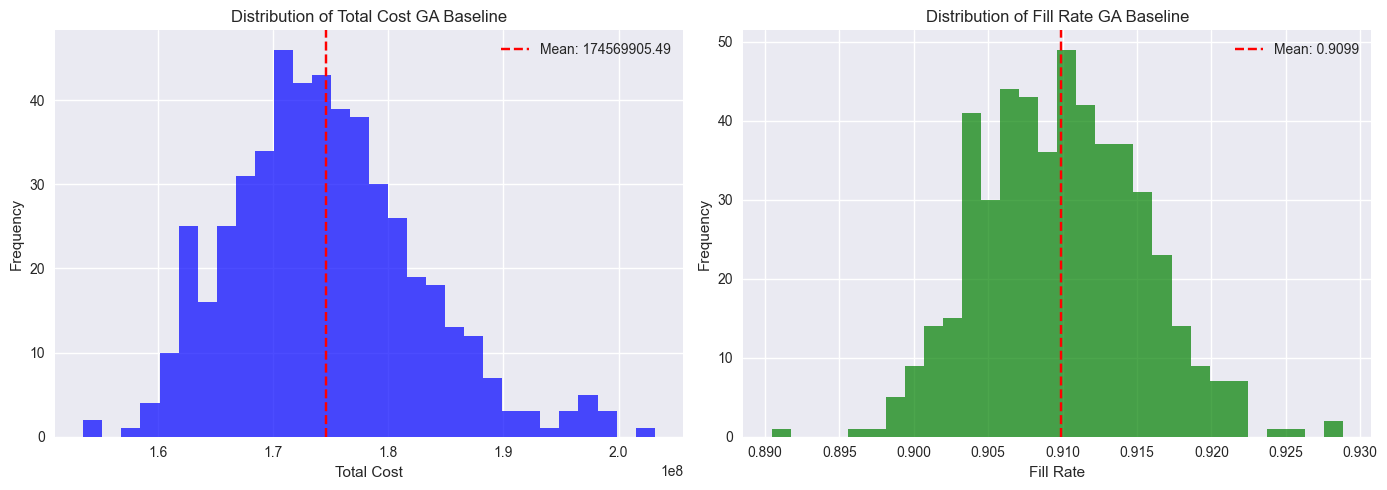

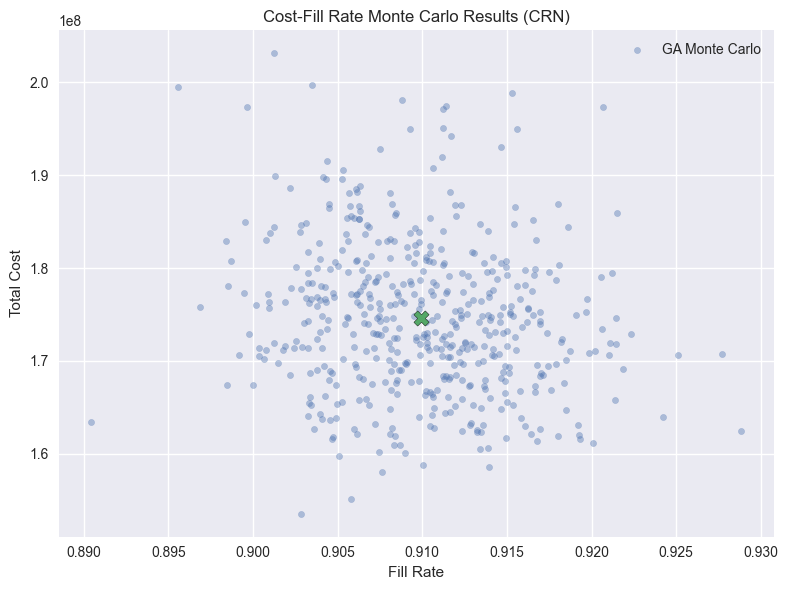

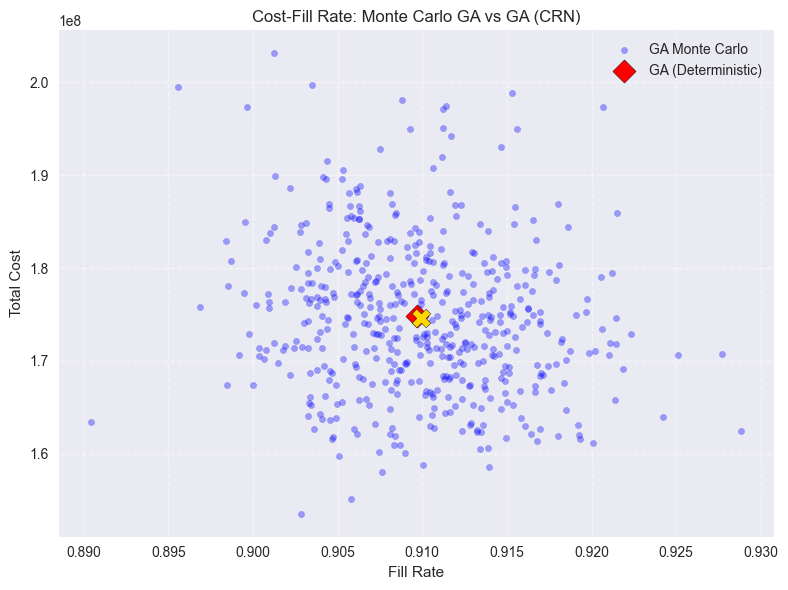

[OK] Clean CSV saved with single deterministic row.
[OK] GA Monte Carlo VS GA paired analysis saved to:
  - MONTE_CARLO_GA_BASELINE_RUNS_4.csv
  - MONTE_CARLO_GA_VS_GA_PAIRED_COMPARISON_4.csv

=== SUMMARY COMPARISON ===
✅ MONTE_CARLO GA has LOWER cost than GA
✅ MONTE_CARLO GA has HIGHER service level than GA

Running Service Level Trade-off Analysis...
Running for service level 0.9...
Gen 20: best=179,709,474.05, mean=41,845,895,700.13, time=0.67 sec
Gen 40: best=179,699,690.65, mean=54,168,774,787.45, time=1.35 sec
Gen 60: best=179,699,690.65, mean=32,565,546,916.10, time=2.08 sec
Gen 80: best=179,699,690.65, mean=94,160,813,165.03, time=3.21 sec
Gen 100: best=179,699,690.65, mean=111,565,719,474.12, time=4.41 sec
Gen 120: best=179,350,575.65, mean=47,011,197,545.69, time=6.08 sec
Gen 140: best=179,350,575.65, mean=118,820,154,150.82, time=7.63 sec
Gen 160: best=179,350,575.65, mean=30,057,487,078.51, time=8.63 sec
Gen 180: best=179,350,575.65, mean=165,556,781,639.49, time=9.45 sec
G

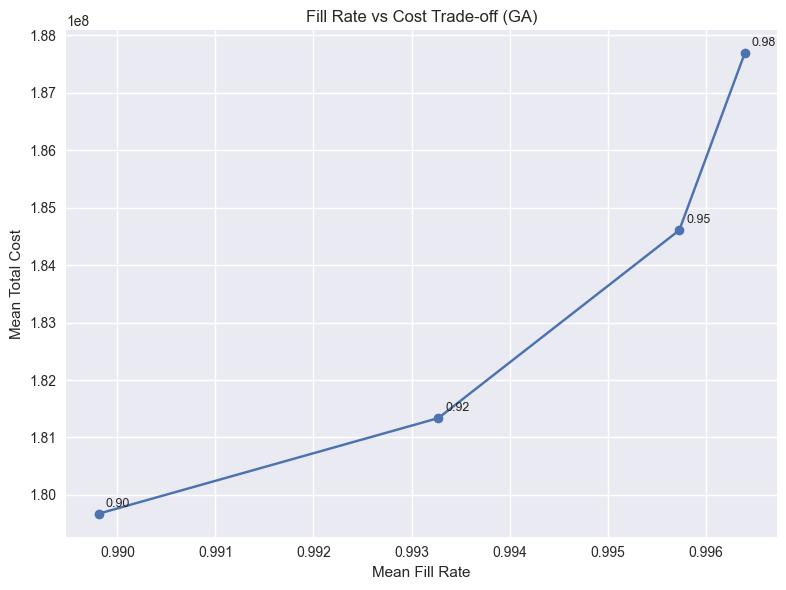

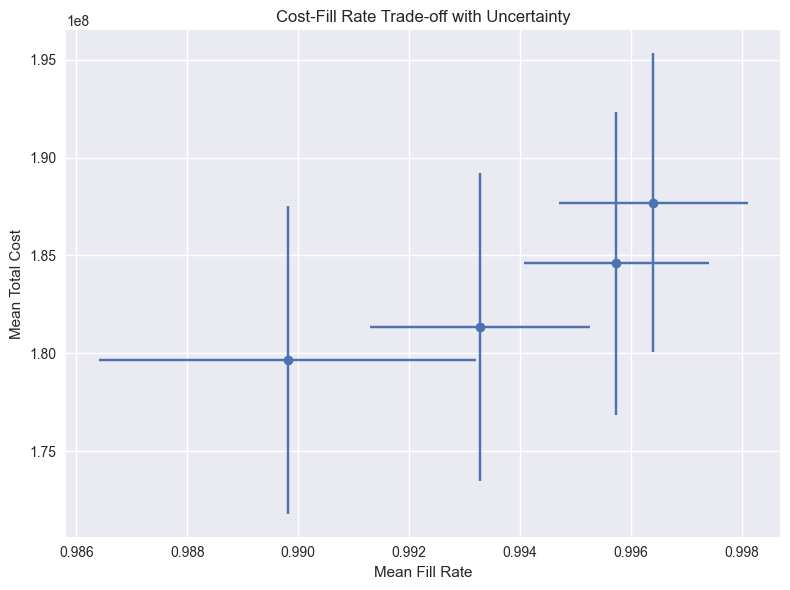

C:\Users\jsantoso\AppData\Local\Temp\ipykernel_32460\135031292.py:633: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)


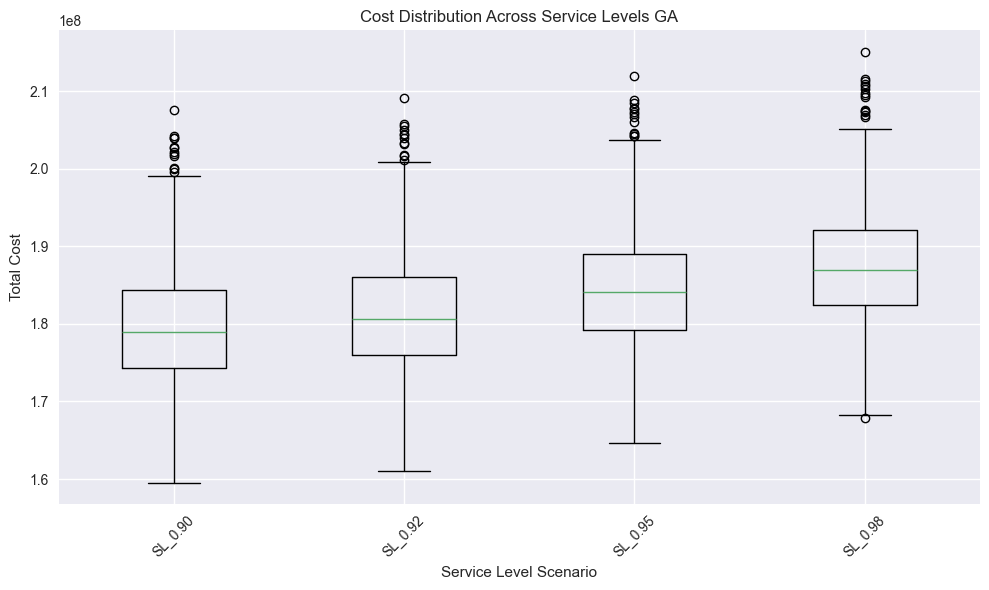

C:\Users\jsantoso\AppData\Local\Temp\ipykernel_32460\135031292.py:651: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)


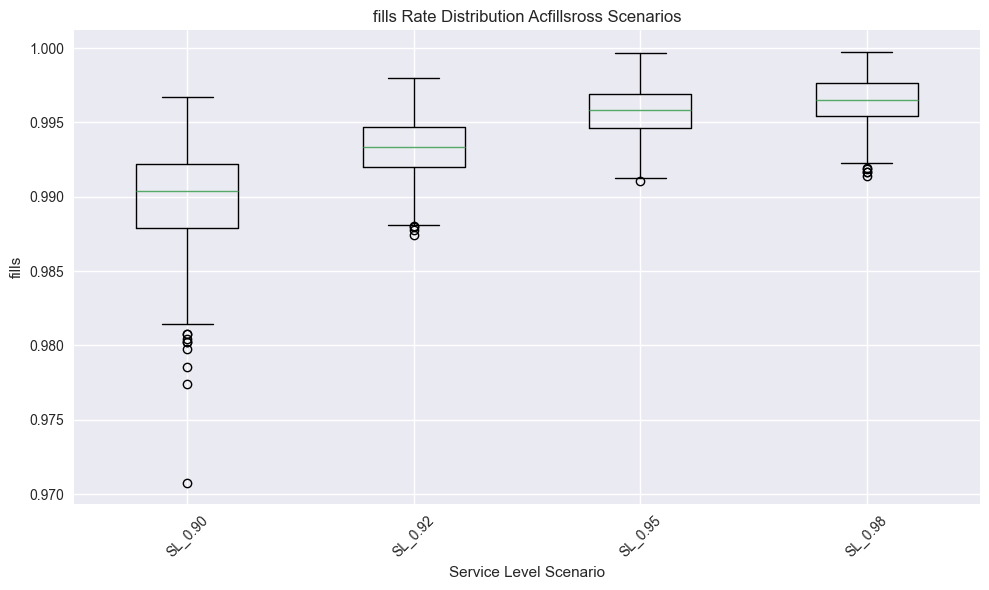

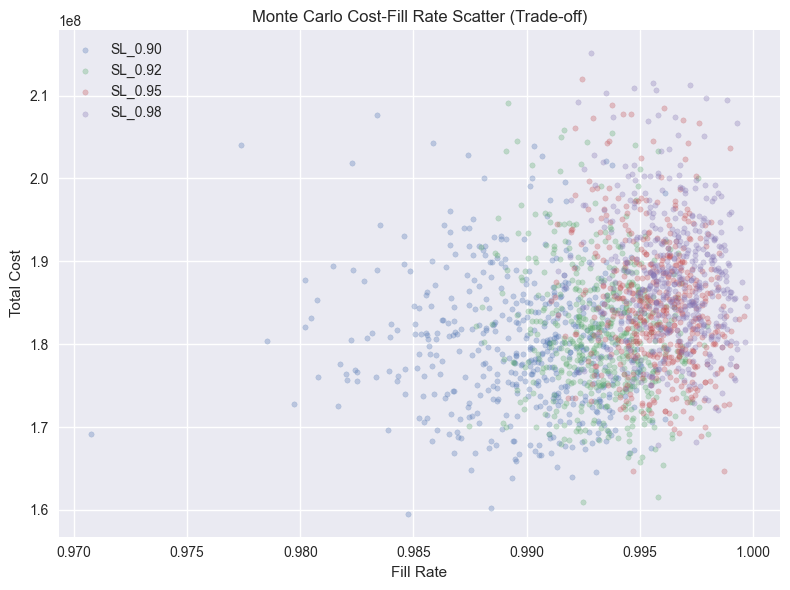

In [36]:
import scipy.stats as stats
from scipy.stats import bootstrap
from pathlib import Path

outdir = Path("output_ga_ipox_2")
outdir.mkdir(parents=True, exist_ok=True)

# Function for Monte Carlo simulation

def compute_mc_cost(Q, SS, D_cust_sim, D_dc_sim):
    holding = float(np.sum(h * (Q / 2.0 + SS)))

    ordering = 0.0
    order_miss_penalty = 0.0
    BIG_COST = 1e12
    for i in range(M):
        for j in range(N):
            Dij = D_dc_sim[i, j]
            Qij = max(Q[i, j], 0)
            if Dij <= 0:
                continue
            if Qij <= 0:
                if USE_MISSED_ORDER_PENALTY and Q_ub[i, j] > 0:  # match compute_cost: only feasible-to-order cells
                    order_miss_penalty += BIG_COST
            else:
                ordering += K[i, j] * (Dij / Qij)

    shortage_cost = 0.0
    shortage_volume = 0.0
    total_demand = 0.0
    for i in range(M):
        S_i = float(np.sum(Q[i] + SS[i]) + SOH_i[i])
        D_i_tot = float(np.sum(D_cust_sim[i]))
        if D_i_tot <= 0.0:
            continue
        B_i_tot = max(0.0, D_i_tot - S_i)
        shortage_volume += B_i_tot
        total_demand += D_i_tot
        if B_i_tot <= 1e-12:
            continue
        alloc = (D_cust_sim[i] / D_i_tot) * B_i_tot
        shortage_cost += float(np.sum(p_ik[i] * alloc))

    pen_budget = 0.0
    BIG_BUDGET_PENALTY = 1e12
    for i in range(M):
        total_inv_cost_i = float(np.sum((Q[i] + SS[i]) * K[i]))
        if total_inv_cost_i > I_i[i]:
            excess_budget = total_inv_cost_i - I_i[i]
            pen_budget += BIG_BUDGET_PENALTY * (excess_budget / max(I_i[i], 1.0))

    pen_cap = pen_qleqd = pen_ss = 0.0
    if USE_PENALTIES:
        cap_violation = np.maximum(Q + SS - C, 0)
        pen_cap = (cap_violation * PENALTY_CAPACITY).sum()

        # Q<=demand is a feasibility constraint on the FIXED plan -> evaluate against the
        # planned (deterministic) assigned demand, exactly like compute_cost. Re-checking it
        # against each random demand realization spuriously triggers the 1e12 wall and makes
        # the mean MC cost explode (you cannot un-order once Q is decided).                
        q_leq_d_violation = np.maximum(Q - D_cust_assigned, 0)
        pen_qleqd = (q_leq_d_violation * PENALTY_Q_LEQ_D).sum()

        ss_deficit = np.maximum(SS_target - SS.sum(axis=1), 0.0)
        pen_ss = float(np.sum(ss_deficit) * PENALTY_SS_TARGET)

        #budget_violation = 0.0
        #K_bar_local = np.where(np.isnan(K).all(axis=1), 0.0, np.nanmean(K, axis=1))
        #for i in range(M):
        #    spend_i = float(np.sum(Q[i] + SS[i]) * max(K_bar_local[i], 0.0))
        #    over = max(0.0, spend_i - float(I_i[i]))
        #    budget_violation += over
        #pen_budget = budget_violation * PENALTY_BUDGET

    fill_rate = 1.0 - (shortage_volume / total_demand) if total_demand > 0 else 1.0
    pen_fill = PENALTY_FILL * max(0.0, TARGET_FILL - fill_rate)  # soft service penalty (matches compute_cost)
    total_basic = holding + ordering + shortage_cost
    total_penalty = order_miss_penalty + pen_cap + pen_qleqd + pen_ss + pen_budget + pen_fill
    total_cost = total_basic + total_penalty
    return total_cost, fill_rate


def monte_carlo_run(Q, SS, num_runs=500, seed=None):
    rng = np.random.default_rng(seed if seed is not None else RANDOM_SEED)
    costs = []
    fills = []
    for _ in range(num_runs):
        if USE_POISSON_SIGMA:
            D_sim = rng.poisson(mu_i)
        else:
            D_sim = rng.normal(mu_i, sigma_i)
        D_sim = np.maximum(D_sim, 0)

        factors = D_sim / np.maximum(mu_i, 1e-9)
        D_cust_sim = D_cust * factors.reshape(-1, 1)
        D_dc_sim = D_dc * factors.reshape(-1, 1)

        total_cost, service_level = compute_mc_cost(Q, SS, D_cust_sim, D_dc_sim)
        costs.append(total_cost)
        fills.append(service_level)

    return np.array(costs), np.array(fills)


def monte_carlo_run_candidates(candidates, num_runs=500, seed=None):
    rng = np.random.default_rng(seed if seed is not None else RANDOM_SEED)
    costs = {name: [] for name, _, _ in candidates}
    fills = {name: [] for name, _, _ in candidates}

    for _ in range(num_runs):
        if USE_POISSON_SIGMA:
            D_sim = rng.poisson(mu_i)
        else:
            D_sim = rng.normal(mu_i, sigma_i)
        D_sim = np.maximum(D_sim, 0)

        factors = D_sim / np.maximum(mu_i, 1e-9)
        D_cust_sim = D_cust * factors.reshape(-1, 1)
        D_dc_sim = D_dc * factors.reshape(-1, 1)

        for name, Q, SS in candidates:
            total_cost, fill_rate = compute_mc_cost(Q, SS, D_cust_sim, D_dc_sim)
            costs[name].append(total_cost)
            fills[name].append(fill_rate)

    return {name: np.array(values) for name, values in costs.items()}, {name: np.array(values) for name, values in fills.items()}


def paired_comparison(name_a, name_b, costs_dict, fills_dict):
    def stats_for(series_a, series_b):
        diff = series_a - series_b
        t_stat, t_p = stats.ttest_rel(series_a, series_b)
        w_stat, w_p = stats.wilcoxon(series_a, series_b, zero_method='wilcox', alternative='two-sided')
        binom_p = stats.binomtest(np.sum(diff > 0), n=len(diff), p=0.5).pvalue
        d = np.mean(diff) / np.std(diff, ddof=1) if np.std(diff, ddof=1) > 0 else np.nan
        rank_biserial = (np.sum(diff > 0) - np.sum(diff < 0)) / len(diff)
        return {
            'mean_diff': float(np.mean(diff)),
            'std_diff': float(np.std(diff, ddof=1)),
            'cohens_d': float(d),
            'rank_biserial': float(rank_biserial),
            'paired_t_stat': float(t_stat),
            'paired_t_pvalue': float(t_p),
            'wilcoxon_stat': float(w_stat),
            'wilcoxon_pvalue': float(w_p),
            'sign_test_pvalue': float(binom_p),
        }

    return {
        'cost_paired': stats_for(costs_dict[name_a], costs_dict[name_b]),
        'fill_paired': stats_for(fills_dict[name_a], fills_dict[name_b]),
    }


# Run Monte Carlo for baseline HGA-VNS and an initial heuristic
print("Running Monte Carlo for candidate solutions with common random numbers...")
Qb0, SSb0 = res['Q_best'], res['SS_best']

candidates = [
    ('GA Monte Carlo', Qb0, SSb0),
    #('GA', Qb0, SSb0),
    
]

costs_all, fill_rate_all = monte_carlo_run_candidates(candidates, num_runs=500, seed=RANDOM_SEED)

costs_base = costs_all['GA Monte Carlo']
fills_base = fill_rate_all['GA Monte Carlo']

mean_cost = np.mean(costs_base)
std_cost = np.std(costs_base)
mean_fill_rate = np.mean(fills_base)
std_fill_rate = np.std(fills_base)

print(f"Baseline GA Monte Carlo Results:")
print(f"Total Cost: Mean = {mean_cost:.2f}, Std = {std_cost:.2f}")
print(f"Service Level: Mean = {mean_fill_rate:.4f}, Std = {std_fill_rate:.4f}")

# Bootstrap confidence intervals
def bootstrap_ci(data, stat_func, confidence=0.95, n_resamples=1000):
    res = bootstrap((data,), stat_func, confidence_level=confidence, n_resamples=n_resamples, method='percentile')
    return res.confidence_interval

ci_cost = bootstrap_ci(costs_base, np.mean)
ci_fill = bootstrap_ci(fills_base, np.mean)
print(f"95% CI for Mean Cost: [{ci_cost.low:.2f}, {ci_cost.high:.2f}]")
print(f"95% CI for Mean Fill Rate: [{ci_fill.low:.4f}, {ci_fill.high:.4f}]")

# Paired tests and nonparametric alternatives
#GA baseline breakdown (approximate from best solution)
det_cost, det_fill = bd['total'], bd['fill_rate']  # approximate

print(f"HGA-VNS Results:")
print(f"Total Cost: Best = {det_cost:.2f}")
print(f"Fill Rate: Best = {det_fill:.4f}")

cost_det_vec = np.full_like(costs_base, det_cost, dtype=float)
fill_det_vec = np.full_like(fills_base, det_fill, dtype=float)

comparison = paired_comparison(
    'GA Monte Carlo', 'GA',
    {
        'GA Monte Carlo': costs_all['GA Monte Carlo'],
        'GA': cost_det_vec
    },
    {
        'GA Monte Carlo': fill_rate_all['GA Monte Carlo'],
        'GA': fill_det_vec
    }
)

#comparison = paired_comparison('GA Monte Carlo', 'GA', costs_all, services_all)
print('\nPaired comparison: GA Monte Carlo vs GA')
for metric in ['cost_paired', 'fill_paired']:
    stats_row = comparison[metric]
    print(f"\n{metric.capitalize()} results:")
    print(f"  - Mean diff = {stats_row['mean_diff']:.2f}")
    print(f"  - Cohen's d = {stats_row['cohens_d']:.4f}")
    print(f"  - Rank biserial = {stats_row['rank_biserial']:.4f}")
    print(f"  - Paired t-test: t = {stats_row['paired_t_stat']:.2f}, p = {stats_row['paired_t_pvalue']:.4f}")
    print(f"  - Wilcoxon signed-rank: W = {stats_row['wilcoxon_stat']:.2f}, p = {stats_row['wilcoxon_pvalue']:.4f}")
    print(f"  - Sign test (binomial): p = {stats_row['sign_test_pvalue']:.4f}")


# Plot distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(costs_base, bins=30, alpha=0.7, color='blue')
ax1.axvline(mean_cost, color='red', linestyle='--', label=f'Mean: {mean_cost:.2f}')
ax1.set_title('Distribution of Total Cost GA Baseline')
ax1.set_xlabel('Total Cost')
ax1.set_ylabel('Frequency')
ax1.legend()

ax2.hist(fills_base, bins=30, alpha=0.7, color='green')
ax2.axvline(mean_fill_rate, color='red', linestyle='--', label=f'Mean: {mean_fill_rate:.4f}')
ax2.set_title('Distribution of Fill Rate GA Baseline')
ax2.set_xlabel('Fill Rate')
ax2.set_ylabel('Frequency')
ax2.legend()

plt.tight_layout()
plt.savefig(outdir / 'Monte_Carlo_GA_Baseline_Distributions_4.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for name in costs_all:
    ax.scatter(fill_rate_all[name], costs_all[name], s=20, alpha=0.4, label=name)
    ax.scatter(np.mean(fill_rate_all[name]), np.mean(costs_all[name]), marker='X', s=120, edgecolors='black')
ax.set_xlabel('Fill Rate')
ax.set_ylabel('Total Cost')
ax.set_title('Cost-Fill Rate Monte Carlo Results (CRN)')
ax.legend()
plt.tight_layout()
plt.savefig(outdir / 'Monte_Carlo_GA_Cost_Fill_Rate_Comparison_4.png', dpi=150)
plt.show()

# Combine both stochastic and deterministic results
fig, ax = plt.subplots(figsize=(8, 6))

costs_plot = {
    'GA Monte Carlo': costs_all['GA Monte Carlo'],
    'GA': cost_det_vec
}
fills_plot = {
    'GA Monte Carlo': fill_rate_all['GA Monte Carlo'],
    'GA': fill_det_vec
}

for name in costs_plot:
    
    if name == 'GA':
        # ✅ Deterministic as SINGLE point (cleaner & correct)
        ax.scatter(
            np.mean(fills_plot[name]),
            np.mean(costs_plot[name]),
            s=140,
            color='red',
            marker='D',
            edgecolors='black',
            label=f"{name} (Deterministic)",
            zorder=6
        )
    else:
        # ✅ Monte Carlo cloud
        ax.scatter(
            fills_plot[name],
            costs_plot[name],
            s=20,
            alpha=0.35,
            color='blue',
            label=name
        )
        
        # ✅ Mean marker for Monte Carlo
        ax.scatter(
            np.mean(fills_plot[name]),
            np.mean(costs_plot[name]),
            marker='X',
            s=180,
            color='gold',
            edgecolors='black',
            zorder=7
        )

# Labels and title
ax.set_xlabel('Fill Rate')
ax.set_ylabel('Total Cost')
ax.set_title('Cost-Fill Rate: Monte Carlo GA vs GA (CRN)', fontsize=12)

# ✅ Remove duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='best')

# ✅ Grid for readability
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(outdir / 'Monte_Carlo_GA_VS_GA_Cost_Service_Comparison_3.png', dpi=150)
plt.show()

candidate_runs = []

# ==================================
# ✅ 1. SAVE MONTE CARLO RUNS
# ==================================
num_runs = len(next(iter(costs_all.values())))  # robust way

for run_id in range(1, num_runs + 1):
    for name in costs_all:
        if 'Monte Carlo' in name:   # ✅ ONLY MC
            candidate_runs.append({
                'run_id': run_id,
                'strategy': name,
                'type': 'MC',                     # ✅ ADD TYPE (IMPORTANT)
                'total_cost': float(costs_all[name][run_id - 1]),
                'service_level': float(fill_rate_all[name][run_id - 1])
            })

# ==================================
# ✅ 2. SAVE DETERMINISTIC (ONLY ONCE)
# ==================================
candidate_runs.append({
    'run_id': 0,
    'strategy': 'GA',
    'type': 'Deterministic',        # ✅ CLEAR LABEL
    'total_cost': float(det_cost),
    'service_level': float(det_fill)
})

# ==================================
# ✅ 3. CREATE DATAFRAME
# ==================================
candidate_runs_df = pd.DataFrame(candidate_runs)

# ==================================
# ✅ 4. SAVE CSV
# ==================================
candidate_runs_df.to_csv(
    outdir / 'MONTE_CARLO_GA_CANDIDATE_RUNS_4_CLEAN.csv',
    index=False
)

print('[OK] Clean CSV saved with single deterministic row.')


pairwise_runs_df = pd.DataFrame(candidate_runs)
pairwise_runs_df.to_csv(outdir / 'MONTE_CARLO_GA_CANDIDATE_RUNS_4.csv', index=False)

comparison_df = pd.DataFrame([
    {
        'metric': 'cost_paired',
        'mean_diff': comparison['cost_paired']['mean_diff'],
        'std_diff': comparison['cost_paired']['std_diff'],
        'cohens_d': comparison['cost_paired']['cohens_d'],
        'rank_biserial': comparison['cost_paired']['rank_biserial'],
        'paired_t_stat': comparison['cost_paired']['paired_t_stat'],
        'paired_t_pvalue': comparison['cost_paired']['paired_t_pvalue'],
        'wilcoxon_stat': comparison['cost_paired']['wilcoxon_stat'],
        'wilcoxon_pvalue': comparison['cost_paired']['wilcoxon_pvalue'],
        'sign_test_pvalue': comparison['cost_paired']['sign_test_pvalue'],
    },
    {
        'metric': 'fill_paired',
        'mean_diff': comparison['fill_paired']['mean_diff'],
        'std_diff': comparison['fill_paired']['std_diff'],
        'cohens_d': comparison['fill_paired']['cohens_d'],
        'rank_biserial': comparison['fill_paired']['rank_biserial'],
        'paired_t_stat': comparison['fill_paired']['paired_t_stat'],
        'paired_t_pvalue': comparison['fill_paired']['paired_t_pvalue'],
        'wilcoxon_stat': comparison['fill_paired']['wilcoxon_stat'],
        'wilcoxon_pvalue': comparison['fill_paired']['wilcoxon_pvalue'],
        'sign_test_pvalue': comparison['fill_paired']['sign_test_pvalue'],
    }
])
comparison_df.to_csv(outdir / 'MONTE_CARLO_GA_VS_GA_PAIRED_COMPARISON_4.csv', index=False)


print(f'[OK] GA Monte Carlo VS GA paired analysis saved to:')
print(f'  - MONTE_CARLO_GA_BASELINE_RUNS_4.csv')
print(f'  - MONTE_CARLO_GA_VS_GA_PAIRED_COMPARISON_4.csv')


comparison_df.set_index('metric', inplace=True)

print('\n=== SUMMARY COMPARISON ===')
if comparison_df.loc['cost_paired','mean_diff'] < 0:
    print('✅ MONTE_CARLO GA has LOWER cost than GA')
else:
    print('⚠️ MONTE_CARLO GA has HIGHER cost than GA')

if comparison_df.loc['fill_paired','mean_diff'] > 0:
    print('✅ MONTE_CARLO GA has HIGHER service level than GA')
else:
    print('⚠️ MONTE_CARLO GA has LOWER service level than GA')

# ============================================
# ✅ TRADE-OFF: SERVICE LEVEL SCENARIO ANALYSIS
# ============================================

def generate_service_scenarios(Q_base, SS_base, scale_grid):
    scenarios = []
    for alpha in scale_grid:
        SS_new = SS_base * alpha
        name = f"SL_scale_{alpha:.2f}"
        scenarios.append((name, Q_base, SS_new))
    return scenarios


def monte_carlo_tradeoff(Q_base, SS_base, scale_grid, num_runs=500, seed=None):
    scenarios = generate_service_scenarios(Q_base, SS_base, scale_grid)

    # Run MC using SAME random numbers (CRN)
    costs_dict, fills_dict = monte_carlo_run_candidates(
        scenarios, num_runs=num_runs, seed=seed
    )

    # Aggregate results
    rows = []
    for name in costs_dict:
        rows.append({
            'scenario': name,
            'scale': float(name.split('_')[-1]),
            'mean_cost': float(np.mean(costs_dict[name])),
            'std_cost': float(np.std(costs_dict[name])),
            'mean_service': float(np.mean(fills_dict[name])),
            'std_service': float(np.std(fills_dict[name]))
        })

    df = pd.DataFrame(rows)
    df.sort_values('mean_service', inplace=True)

    return df, costs_dict, fills_dict


# ============================================
# ✅ RUN TRADE-OFF ANALYSIS
# ============================================

print("\nRunning Service Level Trade-off Analysis...")

# Grid of service level multipliers
#scale_grid = np.linspace(0.6, 1.4, 12)   # adjust resolution

#tradeoff_df, costs_trade, services_trade = monte_carlo_tradeoff(
#    Qb0, SSb0,
#    scale_grid=scale_grid,
#    num_runs=500,
#    seed=RANDOM_SEED
#)

#print(tradeoff_df.head())

# ============================================
# ✅ SERVICE-LEVEL-BASED TRADE-OFF ANALYSIS
# ============================================

def set_env(svc=0.95, seed=None):
    global Z_SERVICE, SS_target, Q0, SS0, SS_lb, SS_ub
    from scipy.stats import norm

    Z_SERVICE = norm.ppf(svc)
    #SS_target = Z_SERVICE * np.sqrt(np.maximum(L_i, 0.0) * np.maximum(sigma_i, 0.0))
    SS_target = Z_SERVICE * sigma_i * np.sqrt(np.maximum(L_i, 0.0))

    D_prop = D_dc / np.maximum(D_dc.sum(axis=1, keepdims=True), 1e-9)
    SS_prop = np.ones_like(D_prop) / N

    Q0 = np.floor((EOQ_i.reshape(-1, 1) * D_prop)).astype(int)
    SS0 = np.ceil((SS_target.reshape(-1, 1) * SS_prop)).astype(int)

    #SS_lb = np.ceil(np.repeat(SS_target.reshape(-1, 1), N, axis=1)).astype(int)
    SS_ub = np.floor(C).astype(int)
    # Align trade-off sweep with the baseline fill-rate targeting: set the SS floor via the
    # budget/capacity-aware coverage allocation for THIS service level, and steer pen_fill to it.
    TARGET_FILL = svc
    SS_lb = np.minimum(_coverage_ss_floor(svc), SS_ub).astype(int)

    if seed is None:
        seed = RANDOM_SEED
    np.random.seed(seed)

svc_levels = [0.90, 0.92, 0.95, 0.98]

trade_off_results = []

# Storage (same structure as before → compatible with boxplot code)
costs_trade = {}
fills_trade = {}

for svc in svc_levels:
    print(f"Running for service level {svc}...")

    # ✅ Set target service level
    set_env(svc=svc)

    # ✅ Reproducibility
    if 'BASE' in globals() and isinstance(BASE, dict) and 'seed' in BASE:
        np.random.seed(BASE['seed'])
    else:
        np.random.seed(RANDOM_SEED)

    # ✅ Re-optimization
    if 'run_ga_vns_hybrid' in globals():
        res = run_ga_vns_hybrid(pop_size=POP_SIZE, generations=GENERATIONS)
    else:
        res = run_ga(pop_size=POP_SIZE, generations=GENERATIONS)

    Q, SS = res['Q_best'], res['SS_best']

    # ✅ Monte Carlo evaluation
    costs, fills = monte_carlo_run(Q, SS, num_runs=500)

    # ✅ Store distributions (important for boxplot)
    scenario_name = f"SL_{svc:.2f}"
    costs_trade[scenario_name] = costs
    fills_trade[scenario_name] = fills

    # ✅ Aggregate metrics
    mean_c = np.mean(costs)
    std_c = np.std(costs)
    mean_f = np.mean(fills)
    std_f = np.std(fills)

    trade_off_results.append({
        'svc_target': svc,
        'mean_cost': mean_c,
        'std_cost': std_c,
        'mean_fill': mean_f,
        'std_fill': std_f
    })

# ============================================
# ✅ DATAFRAME (FOR CSV + ANALYSIS)
# ============================================

tradeoff_df = pd.DataFrame(trade_off_results)
tradeoff_df.sort_values('mean_fill', inplace=True)

print(tradeoff_df)

tradeoff_df.to_csv(
    outdir / 'TRADEOFF_SERVICE_TARGET_RESULTS_GA_4.csv',
    index=False
)

print("[OK] Service-level trade-off results saved")

#1. Trade-off Curve (MAIN import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

# Sort ensures smooth curve
df_plot = tradeoff_df.sort_values('mean_fill')

ax.plot(
    df_plot['mean_fill'],
    df_plot['mean_cost'],
    marker='o',
    linestyle='-'
)

# Annotate service targets
for _, row in df_plot.iterrows():
    ax.annotate(
        f"{row['svc_target']:.2f}",
        (row['mean_fill'], row['mean_cost']),
        textcoords="offset points",
        xytext=(5,5),
        fontsize=9
    )

ax.set_xlabel('Mean Fill Rate')
ax.set_ylabel('Mean Total Cost')
ax.set_title('Fill Rate vs Cost Trade-off (GA)')
ax.grid(True)

plt.tight_layout()
plt.savefig(outdir / 'TRADEOFF_COST_SERVICE_CURVE_GA_4.png', dpi=150)
plt.show()

#2. Error Bar Plot (adds uncertainty)
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(
    tradeoff_df['mean_fill'],
    tradeoff_df['mean_cost'],
    xerr=tradeoff_df['std_fill'],
    yerr=tradeoff_df['std_cost'],
    fmt='o',
    capsize=5
)

ax.set_xlabel('Mean Fill Rate')
ax.set_ylabel('Mean Total Cost')
ax.set_title('Cost-Fill Rate Trade-off with Uncertainty')
ax.grid(True)

plt.tight_layout()
plt.savefig(outdir / 'TRADEOFF_WITH_ERROR_BARS_GA_4.png', dpi=150)
plt.show()

#3. Boxplots
#Shows full distributions per service level
#Cost distribution:

fig, ax = plt.subplots(figsize=(10, 6))

labels = list(costs_trade.keys())
data = [costs_trade[k] for k in labels]

ax.boxplot(data, labels=labels)

ax.set_xlabel('Service Level Scenario')
ax.set_ylabel('Total Cost')
ax.set_title('Cost Distribution Across Service Levels GA')
ax.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(outdir / 'TRADEOFF_COST_BOXPLOT_GA_4.png', dpi=150)
plt.show()

#Service distribution:
fig, ax = plt.subplots(figsize=(10, 6))

labels = list(fills_trade.keys())
data = [fills_trade[k] for k in labels]

ax.boxplot(data, labels=labels)

ax.set_xlabel('Service Level Scenario')
ax.set_ylabel('fills')
ax.set_title('fills Rate Distribution Acfillsross Scenarios')
ax.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(outdir / 'TRADEOFF_FILL_RATE_BOXPLOT_GA_4.png', dpi=150)
plt.show()

#4. Scatter Cloud (optional but insightful)
fig, ax = plt.subplots(figsize=(8, 6))

for name in costs_trade:
    ax.scatter(
        fills_trade[name],
        costs_trade[name],
        alpha=0.3,
        s=15,
        label=name
    )

ax.set_xlabel('Fill Rate')
ax.set_ylabel('Total Cost')
ax.set_title('Monte Carlo Cost-Fill Rate Scatter (Trade-off)')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig(outdir / 'TRADEOFF_SCATTER_GA_4.png', dpi=150)
plt.show()



## Parameter Sensitivity – CSV + Delta + ROP + Per-Param + Grafik + Aggregator

In [37]:
ENGINE_NAME = "GA"

Z_TABLE = {0.90:1.2816, 0.92:1.4051, 0.95:1.6449, 0.96:1.7507, 0.97:1.8808, 0.98:2.0537}

def z_from_service(p: float) -> float:
    p = round(float(p), 2)
    if p in Z_TABLE: return Z_TABLE[p]
    keys = sorted(Z_TABLE.keys(), key=lambda x: abs(x-p))
    return Z_TABLE[keys[0]]


# ===================== Parameter Sensitivity (CSV + Delta + ROP + Per-Param + PNG + Aggregator) =====================
from copy import deepcopy
import os

outdir = Path('scenarios_out'); outdir.mkdir(parents=True, exist_ok=True)
rows = []

# Baseline definiton
BASE = {
    'svc': 0.95,
    'lt_fac': 1.00,
    'bfac': 1.00,
    'logc': 20.0,
    'pop': POP_SIZE,
    'gens': GENERATIONS,
    'kmax': K_MAX,
    'ls_max_iters': LS_MAX_ITERS,
    'seed': RANDOM_SEED,
}

# Simpan baseline copies untuk reset cepat
h_base = h.copy(); L_i_base = L_i.copy(); I_i_base = I_i.copy()

# Helper update env

def set_env(svc=None, lt_fac=None, bfac=None, logc=None):
    global Z_SERVICE, L_i, I_i, h, SS_target
    if svc is None: svc = BASE['svc']
    if lt_fac is None: lt_fac = BASE['lt_fac']
    if bfac is None: bfac = BASE['bfac']
    if logc is None: logc = BASE['logc']
    Z_SERVICE = z_from_service(svc)
    L_i = L_i_base * lt_fac
    mu = D_tot.astype(float)
    sig = np.sqrt(np.maximum(mu,0.0)) if USE_POISSON_SIGMA else np.array([SIGMA_OVERRIDE.get(i+1, np.sqrt(max(mu[i],0.0))) for i in range(M)])
    SS_target = Z_SERVICE * np.sqrt(np.maximum(L_i,0.0) * np.maximum(sig,0.0))
    I_i[:] = I_i_base * bfac
    h[:,:] = h_base + float(logc)

# Jalankan BASELINE sekali
set_env(svc=BASE['svc'], lt_fac=BASE['lt_fac'], bfac=BASE['bfac'], logc=BASE['logc'])
np.random.seed(BASE['seed'])
POP_SIZE, GENERATIONS, K_MAX, LS_MAX_ITERS = BASE['pop'], BASE['gens'], BASE['kmax'], BASE['ls_max_iters']
if 'run_ga_vns_hybrid' in globals():
    res_base = run_ga_vns_hybrid(pop_size=POP_SIZE, generations=GENERATIONS)
elif 'vns_multistart' in globals() and 'run_ga' not in globals():
    res_base = vns_multistart(best_nstarts=N_STARTS)
else:
    res_base = run_ga(pop_size=POP_SIZE, generations=GENERATIONS)

# Hitung metrik baseline
Qb0, SSb0 = res_base['Q_best'], res_base['SS_best']
ROPb0 = compute_rop(Qb0, SSb0)
base_bd = res_base['breakdown']
BASE_METRIC = {
    'total': float(base_bd.get('total', np.nan)),
    'holding': float(base_bd.get('holding', np.nan)),
    'ordering': float(base_bd.get('ordering', np.nan)),
    'shortage': float(base_bd.get('shortage', np.nan)),
    'order_miss_penalty': float(base_bd.get('order_miss_penalty', np.nan)),
    'sum_Q': float(np.sum(Qb0)),
    'sum_SS': float(np.sum(SSb0)),
    'sum_ROP': float(np.sum(ROPb0)),
}

# Summary row builder + delta vs baseline

def summarize(param_name, param_value, res, Q, SS):
    ROP = compute_rop(Q, SS)
    bd = res['breakdown']
    rec = {
        'param': param_name,
        'value': param_value,
        'total': float(bd.get('total', np.nan)),
        'holding': float(bd.get('holding', np.nan)),
        'ordering': float(bd.get('ordering', np.nan)),
        'shortage': float(bd.get('shortage', np.nan)),
        'order_miss_penalty': float(bd.get('order_miss_penalty', np.nan)),
        'sum_Q': float(np.sum(Q)),
        'sum_SS': float(np.sum(SS)),
        'sum_ROP': float(np.sum(ROP)),
        'convergence_sec': float(res.get('convergence_sec', np.nan)),
        'pop': POP_SIZE, 'gens': GENERATIONS, 'kmax': K_MAX, 'ls_max_iters': LS_MAX_ITERS, 'seed': BASE['seed'],
        'svc': Z_SERVICE,
        'lt_fac': float(np.mean(L_i)/float(np.mean(L_i_base)) if np.mean(L_i_base)>0 else np.nan),
        'bfac': float(I_i[0]/I_i_base[0]) if I_i_base[0]>0 else np.nan,
        'logc': float(h[0,0]-h_base[0,0])
    }
    # Delta vs baseline
    rec.update({
        'delta_total': rec['total'] - BASE_METRIC['total'],
        'delta_holding': rec['holding'] - BASE_METRIC['holding'],
        'delta_ordering': rec['ordering'] - BASE_METRIC['ordering'],
        'delta_shortage': rec['shortage'] - BASE_METRIC['shortage'],
        'delta_order_miss_penalty': rec['order_miss_penalty'] - BASE_METRIC['order_miss_penalty'],
        'delta_sum_Q': rec['sum_Q'] - BASE_METRIC['sum_Q'],
        'delta_sum_SS': rec['sum_SS'] - BASE_METRIC['sum_SS'],
        'delta_sum_ROP': rec['sum_ROP'] - BASE_METRIC['sum_ROP'],
    })
    return rec

# --------------------- SENSITIVITY RUNS ---------------------
PARAM_SWEEPS = [
    ('service_level', [0.90, 0.92, 0.95, 0.96, 0.97, 0.98]),    
    ('lt_factor', [0.75, 1.25, 0.50, 1.50, 0.25, 1.75]),              #[0.75, 1.25, 0.50, 1.50]
    ('budget_factor', [1.00, 1.20, 1.50, 1.70, 2.0]),                 #[1.00, 1.20, 1.50]    
    ('log_cost', [10.0, 20.0, 30.0, 40.0, 50.0]),                     #[10.0, 20.0, 30.0]
]
# Metaheuristic-only params (GA/Hybrid/VNS). For MILP, this list will be ignored.
META_SWEEPS = [
    ('pop_size', [40, 80, 120, 160, 200]),                      #[40, 80, 120]
    ('iterations', [100, 200, 300, 400, 500]),                  #[100, 200, 300]    
    ('neighborhood_kmax', [3, 5, 7, 9, 11]),                    #[3, 5, 7]
    ('ls_max_iters', [50, 80, 120, 160, 200]),                  #[50, 80, 120]
    ('seed', [42, 99, 123, 147, 171]),                          #[42, 99, 123]
]

# run sweeps common
for name, vals in PARAM_SWEEPS:
    for v in vals:
        if name=='service_level': set_env(svc=v)
        elif name=='lt_factor': set_env(lt_fac=v)
        elif name=='budget_factor': set_env(bfac=v)
        elif name=='log_cost': set_env(logc=v)
        np.random.seed(BASE['seed'])
        POP_SIZE, GENERATIONS, K_MAX, LS_MAX_ITERS = BASE['pop'], BASE['gens'], BASE['kmax'], BASE['ls_max_iters']
        if 'run_ga_vns_hybrid' in globals():
            res = run_ga_vns_hybrid(pop_size=POP_SIZE, generations=GENERATIONS)
        elif 'vns_multistart' in globals() and 'run_ga' not in globals():
            res = vns_multistart(best_nstarts=N_STARTS)
        else:
            res = run_ga(pop_size=POP_SIZE, generations=GENERATIONS)
        rows.append(summarize(name, v, res, res['Q_best'], res['SS_best']))

# meta sweeps if available
if 'run_ga' in globals() or 'run_ga_vns_hybrid' in globals() or 'vns_multistart' in globals():
    for name, vals in META_SWEEPS:
        for v in vals:
            set_env()
            if name=='pop_size':
                np.random.seed(BASE['seed']); POP_SIZE=int(v); GENERATIONS=BASE['gens']; K_MAX=BASE['kmax']; LS_MAX_ITERS=BASE['ls_max_iters']
            elif name=='iterations':
                np.random.seed(BASE['seed']); POP_SIZE=BASE['pop']; GENERATIONS=int(v); K_MAX=BASE['kmax']; LS_MAX_ITERS=BASE['ls_max_iters']
            elif name=='neighborhood_kmax':
                np.random.seed(BASE['seed']); POP_SIZE=BASE['pop']; GENERATIONS=BASE['gens']; K_MAX=int(v); LS_MAX_ITERS=BASE['ls_max_iters']
            elif name=='ls_max_iters':
                np.random.seed(BASE['seed']); POP_SIZE=BASE['pop']; GENERATIONS=BASE['gens']; K_MAX=BASE['kmax']; LS_MAX_ITERS=int(v)
            elif name=='seed':
                np.random.seed(int(v)); POP_SIZE=BASE['pop']; GENERATIONS=BASE['gens']; K_MAX=BASE['kmax']; LS_MAX_ITERS=BASE['ls_max_iters']
            if 'run_ga_vns_hybrid' in globals():
                res = run_ga_vns_hybrid(pop_size=POP_SIZE, generations=GENERATIONS)
            elif 'vns_multistart' in globals() and 'run_ga' not in globals():
                res = vns_multistart(best_nstarts=N_STARTS)
            else:
                res = run_ga(pop_size=POP_SIZE, generations=GENERATIONS)
            rec = summarize(name, v, res, res['Q_best'], res['SS_best'])
            if name=='pop_size': rec.update({'pop':int(v)})
            if name=='iterations': rec.update({'gens':int(v)})
            if name=='neighborhood_kmax': rec.update({'kmax':int(v)})
            if name=='ls_max_iters': rec.update({'ls_max_iters':int(v)})
            if name=='seed': rec.update({'seed':int(v)})
            rows.append(rec)

# ===== Save CSV summary (generic + engine-specific) =====
df = pd.DataFrame(rows)
df.to_csv(outdir/'PARAM_SENSITIVITY_SUMMARY.csv', index=False)
df.to_csv(outdir/f'PARAM_SENSITIVITY_SUMMARY_{ENGINE_NAME}.csv', index=False)

# ===== Save per-parameter CSV =====
param_files = {
    'service_level': 'SENS_service_level.csv',
    'lt_factor': 'SENS_lt_factor.csv',
    'budget_factor': 'SENS_budget_factor.csv',
    'log_cost': 'SENS_log_cost.csv',
    'pop_size': 'SENS_pop_size.csv',
    'iterations': 'SENS_iterations.csv',
    'neighborhood_kmax': 'SENS_neighborhood_kmax.csv',
    'ls_max_iters': 'SENS_ls_max_iters.csv',
    'seed': 'SENS_seed.csv',
}
for p, fname in param_files.items():
    sub = df[df['param']==p]
    if not sub.empty:
        sub.to_csv(outdir/fname, index=False)

print('[OK] PARAM_SENSITIVITY_SUMMARY (+engine) + per-parameter CSV tersimpan')

# ===== Plotting =====
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')
SENS_PLOTS_DIR = outdir
BREAKDOWN_COLS = ['holding','ordering','shortage','order_miss_penalty']

# Helper plot

def _ensure_order(df, param):
    d = df[df['param']==param].copy()
    if d.empty:
        return d
    try:
        d['value_num'] = pd.to_numeric(d['value'])
        d = d.sort_values('value_num')
        d = d.drop(columns=['value_num'])
    except Exception:
        d = d.sort_values('value')
    return d

def _plot_line(df, x, y, title, xlabel, ylabel, fname, color='#1f77b4'):
    if df.empty: return
    fig, ax = plt.subplots(figsize=(8,4.5))
    ax.plot(df[x], df[y], marker='o', linewidth=2, color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle='--', alpha=0.4)
    fig.tight_layout()
    fig.savefig(SENS_PLOTS_DIR / fname, dpi=150)
    plt.close(fig)

def _plot_stack_breakdown(df, x, parts, title, xlabel, ylabel, fname):
    if df.empty: return
    fig, ax = plt.subplots(figsize=(8,4.5))
    bottom = None
    colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']
    for idx, col in enumerate(parts):
        vals = df[col].values
        if bottom is None:
            ax.bar(df[x].astype(str), vals, label=col, color=colors[idx % len(colors)])
            bottom = vals
        else:
            ax.bar(df[x].astype(str), vals, bottom=bottom, label=col, color=colors[idx % len(colors)])
            bottom = bottom + vals
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    fig.tight_layout()
    fig.savefig(SENS_PLOTS_DIR / fname, dpi=150)
    plt.close(fig)

# Generate plots for each parameter present in df
PARAM_LIST = list(param_files.keys())
for p in PARAM_LIST:
    d = _ensure_order(df, p)
    if d.empty: 
        continue
    # Total cost
    _plot_line(d, x='value', y='total', 
               title=f'[{ENGINE_NAME}] Total Cost vs {p}',
               xlabel=p, ylabel='Total Cost', 
               fname=f'SENS_{p}_total_{ENGINE_NAME}.png')
    # Stacked breakdown
    _plot_stack_breakdown(d, x='value', parts=[c for c in BREAKDOWN_COLS if c in d.columns],
                          title=f'[{ENGINE_NAME}] Breakdown Biaya vs {p}',
                          xlabel=p, ylabel='Biaya', 
                          fname=f'SENS_{p}_breakdown_{ENGINE_NAME}.png')
    # Convergence time
    if 'convergence_sec' in d.columns:
        _plot_line(d, x='value', y='convergence_sec', 
                   title=f'[{ENGINE_NAME}] Waktu Konvergensi vs {p}',
                   xlabel=p, ylabel='Detik', 
                   fname=f'SENS_{p}_convergence_{ENGINE_NAME}.png', color='#9467bd')
    # Delta plots (Delta Total)
    _plot_line(d, x='value', y='delta_total',
               title=f'[{ENGINE_NAME}] ΔTotal vs {p} (baseline=svc95%,lt1.0,bf1.0,log20)',
               xlabel=p, ylabel='ΔTotal', 
               fname=f'SENS_{p}_delta_total_{ENGINE_NAME}.png', color='#d62728')

print('[OK] PNG grafik sensitivitas + delta tersimpan di scenarios_out/.')

# ===== Cross-method aggregator & comparison plots =====
# Kumpulkan semua file *_ENGINE.csv (jika ada) dan gabungkan
all_files = sorted(outdir.glob('PARAM_SENSITIVITY_SUMMARY_*.csv'))
agg_rows = []
for f in all_files:
    try:
        df_e = pd.read_csv(f)
        # engine inference from filename suffix
        m = re.search(r'PARAM_SENSITIVITY_SUMMARY_(.*)\.csv$', f.name)
        eng = m.group(1) if m else ENGINE_NAME
        df_e['engine'] = eng
        agg_rows.append(df_e)
    except Exception as e:
        print('skip', f, e)

if agg_rows:
    ALL = pd.concat(agg_rows, ignore_index=True)
    ALL.to_csv(outdir/'ALL_METHODS_PARAM_SENSITIVITY.csv', index=False)
    # Bandingkan per-parameter (Total & Delta Total) antar engine
    for p in PARAM_LIST:
        d = ALL[ALL['param']==p].copy()
        if d.empty: continue
        # Try cast value numeric for sort/plot
        try:
            d['value_num'] = pd.to_numeric(d['value'])
            d = d.sort_values(['value_num','engine'])
            xcol='value_num'
        except:
            xcol='value'
        # Total by engine
        fig, ax = plt.subplots(figsize=(8,4.5))
        for eng, g in d.groupby('engine'):
            ax.plot(g[xcol], g['total'], marker='o', linewidth=2, label=str(eng))
        ax.set_title(f'Perbandingan Total vs {p} (lintas metode)')
        ax.set_xlabel(p); ax.set_ylabel('Total Cost'); ax.grid(True, ls='--', alpha=0.4); ax.legend()
        fig.tight_layout(); fig.savefig(outdir/f'COMP_{p}_total_by_engine.png', dpi=150); plt.close(fig)
        # Delta total by engine
        if 'delta_total' in d.columns:
            fig, ax = plt.subplots(figsize=(8,4.5))
            for eng, g in d.groupby('engine'):
                ax.plot(g[xcol], g['delta_total'], marker='o', linewidth=2, label=str(eng))
            ax.set_title(f'Perbandingan ΔTotal vs {p} (lintas metode)')
            ax.set_xlabel(p); ax.set_ylabel('ΔTotal'); ax.grid(True, ls='--', alpha=0.4); ax.legend()
            fig.tight_layout(); fig.savefig(outdir/f'COMP_{p}_delta_total_by_engine.png', dpi=150); plt.close(fig)

    print('[OK] Aggregator: ALL_METHODS_PARAM_SENSITIVITY.csv + comparison plots dibuat')
else:
    print('[WARN] Belum ada file *_ENGINE.csv untuk agregasi lintas metode. Jalankan sensitivity di tiap notebook dulu.')


Gen 20: best=187,453,183.65, mean=33,521,140,297.27, time=1.69 sec
Gen 40: best=187,453,183.65, mean=55,815,392,260.99, time=3.56 sec
Gen 60: best=187,453,183.65, mean=33,196,869,501.82, time=5.82 sec
Gen 80: best=187,453,183.65, mean=97,769,312,009.12, time=7.34 sec
Gen 100: best=187,453,183.65, mean=112,684,587,111.65, time=8.77 sec
Gen 120: best=187,453,183.65, mean=47,441,605,735.91, time=10.36 sec
Gen 140: best=187,453,183.65, mean=126,796,298,235.26, time=11.72 sec
Gen 160: best=187,453,183.65, mean=30,065,585,719.84, time=13.08 sec
Gen 180: best=187,453,183.65, mean=167,198,229,917.49, time=14.20 sec
Gen 200: best=187,453,183.65, mean=78,656,125,804.25, time=15.68 sec
Gen 220: best=187,453,183.65, mean=69,587,265,039.52, time=17.04 sec
Gen 240: best=187,453,183.65, mean=8,598,667,660.03, time=18.31 sec
Gen 260: best=187,453,183.65, mean=54,423,815,504.73, time=19.52 sec
Gen 280: best=187,453,183.65, mean=82,637,733,562.99, time=20.67 sec
Gen 300: best=187,453,183.65, mean=31,772